In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## §0 — Imports and Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats, signal as scipy_signal
from scipy.spatial.distance import hamming
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import itertools

# ── Reproducibility
np.random.seed(42)

# ── Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# ── SAX alphabet
ALPHABET = 'abcde'          # size W=5 (reviewer: alphabet size must be stated)
ALPHABET_SIZE = len(ALPHABET)

# ── RQA parameters (reviewer: m, τ, ε must be stated)
RQA_M   = 3     # embedding dimension  — chosen via FNN (see §4a)
RQA_TAU = 1     # time delay           — chosen via AMI (see §4a)
RQA_EPS = 0.20  # recurrence threshold — 20% of max distance (standard practice)

# ── DFA segment sizes (reviewer: scales must be stated)
DFA_SCALES = [4, 5, 6]  # three non-overlapping segment sizes for N≈15-segment series

print('Configuration loaded.')
print(f'  SAX alphabet size : {ALPHABET_SIZE} ({ALPHABET})')
print(f'  RQA m={RQA_M}, τ={RQA_TAU}, ε={RQA_EPS}')
print(f'  DFA scales        : {DFA_SCALES}')

Configuration loaded.
  SAX alphabet size : 5 (abcde)
  RQA m=3, τ=1, ε=0.2
  DFA scales        : [4, 5, 6]


## §1 — Load and Explore Expanded Dataset

In [ ]:
# ── Load dataset
BASE_DIR = "/content/drive/MyDrive/Chlorophyll_analysis/"
df_raw = pd.read_excel(BASE_DIR+
    'chlorophyll_readings.xlsx',
    sheet_name='Sheet 1',
    usecols=['Site_ID', 'Time', 'Chl Temp (°C)', 'Chlorophyll (µg/L)']
)
df_raw.columns = ['Site_ID', 'Time', 'chl_temp', 'chlorophyll']
df_raw['Time'] = pd.to_datetime(df_raw['Time'], errors='coerce')
df_raw = df_raw.dropna(subset=['chlorophyll'])

# ── Per-site summary
summary = df_raw.groupby('Site_ID')['chlorophyll'].agg(
    n='count', mean='mean', std='std',
    min='min', median='median', max='max'
).round(3)
print(f'Total readings : {len(df_raw):,}')
print(f'Sites          : {df_raw.Site_ID.nunique()}')
print()
print(summary.to_string())

Total readings : 7,328
Sites          : 13

                                         n     mean      std    min  median     max
Site_ID                                                                            
S1-Ulhas River                         599   46.551    9.871    2.5    49.1   54.80
S10-Chivla River                       632  202.473    1.110  200.8   202.0  204.90
S11- Chlorella Vulgaris concentration  540  111.080    2.245  106.7   111.4  115.10
S12- Tap Water                         450    0.000    0.002    0.0     0.0    0.03
S13- Distilled Water                   465    0.000    0.000    0.0     0.0    0.00
S2-Kalu River                          524  112.135  114.085    0.0    44.6  294.50
S3-Ambernath Lake                      519  259.046    0.301  258.5   259.0  259.70
S4-Bhandup Lake                        534  216.684    6.238  205.9   218.1  228.50
S5-Dhamapur Lake                       648  191.072    5.288  187.2   188.4  225.30
S6-Shirpur Lake                 

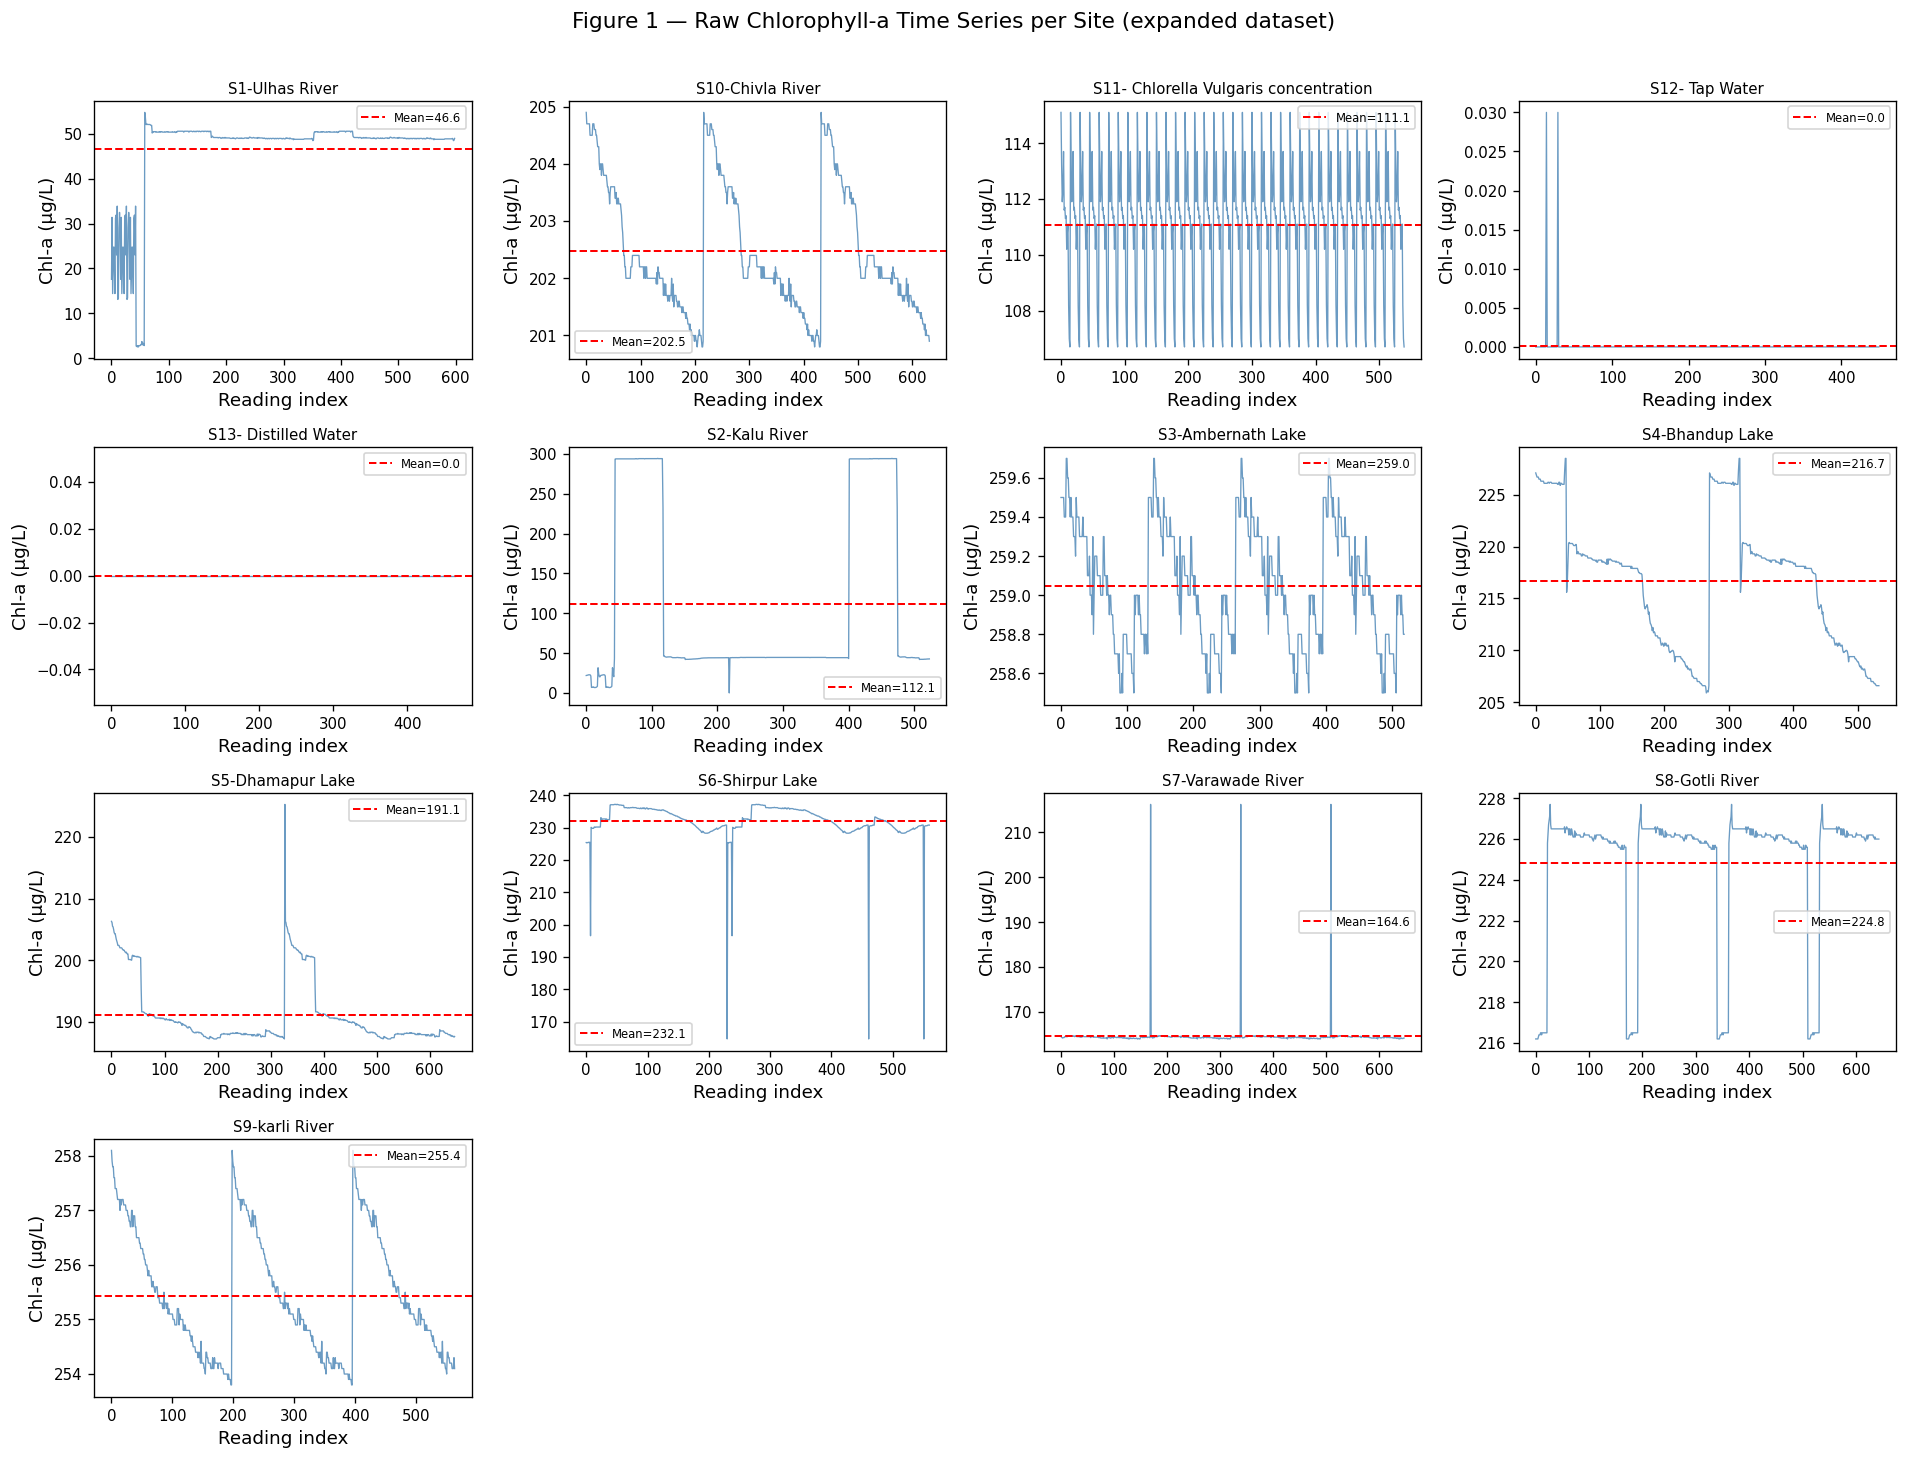

In [ ]:
# ── Visualise raw distributions per site
sites = df_raw['Site_ID'].unique()
n_sites = len(sites)
cols = 4
rows = (n_sites + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, site in enumerate(sorted(sites)):
    grp = df_raw[df_raw.Site_ID == site]['chlorophyll']
    axes[i].plot(grp.values, lw=0.8, color='steelblue', alpha=0.8)
    axes[i].axhline(grp.mean(), color='red', lw=1.2, linestyle='--', label=f'Mean={grp.mean():.1f}')
    axes[i].set_title(site, fontsize=9, pad=4)
    axes[i].set_xlabel('Reading index')
    axes[i].set_ylabel('Chl-a (µg/L)')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Figure 1 — Raw Chlorophyll-a Time Series per Site (expanded dataset)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig1_raw_timeseries.png', bbox_inches='tight')
plt.show()

## §2 — Signal Preprocessing: Noise Analysis and Savitzky–Golay Filtering

In [ ]:
# ── 2a: Noise characterisation from distilled-water baseline
distilled = df_raw[df_raw.Site_ID == 'S13- Distilled Water']['chlorophyll']
noise_mean = distilled.mean()
noise_std  = distilled.std()
noise_snr  = df_raw[df_raw.Site_ID != 'S13- Distilled Water']['chlorophyll'].mean() / (noise_std + 1e-9)

print('=== Sensor Noise Characterisation (Distilled Water Baseline) ===')
print(f'  Baseline mean : {noise_mean:.4f} µg/L')
print(f'  Baseline std  : {noise_std:.4f} µg/L  (instrumental noise floor)')
print(f'  CV            : {noise_std / (noise_mean + 1e-9) * 100:.2f}%')
print(f'  Avg signal-to-noise ratio (all natural sites): {noise_snr:.1f}')

=== Sensor Noise Characterisation (Distilled Water Baseline) ===
  Baseline mean : 0.0000 µg/L
  Baseline std  : 0.0000 µg/L  (instrumental noise floor)
  CV            : 0.00%
  Avg signal-to-noise ratio (all natural sites): 171102456651.6


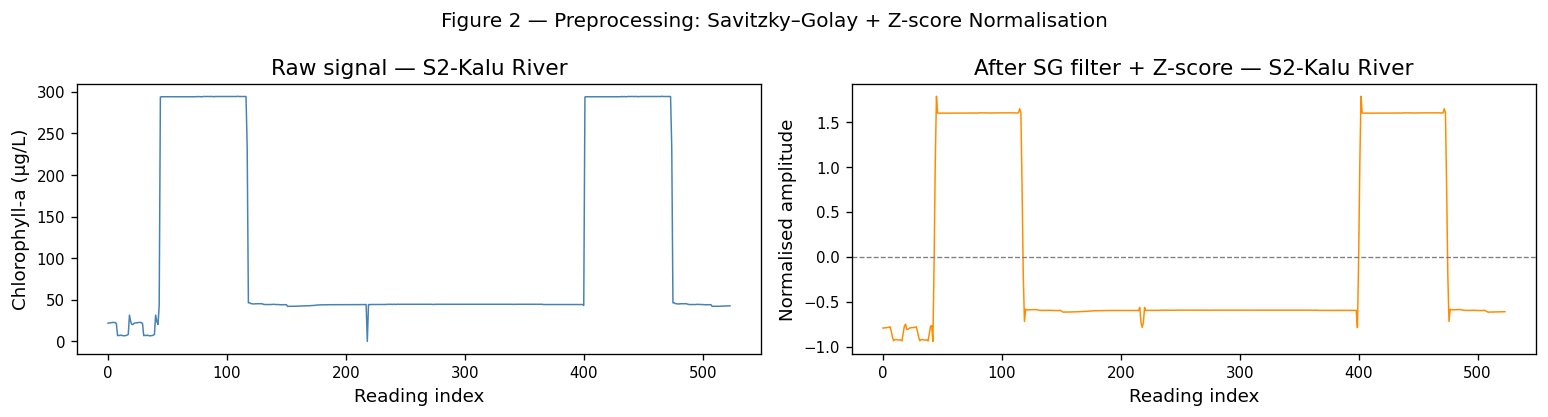

SG filter: window=5, polyorder=2  |  Z-score applied per site


In [ ]:
# ── 2b: Apply Savitzky-Golay filter and Z-score normalisation
def preprocess(series, sg_window=5, sg_poly=2):
    """Savitzky-Golay smoothing followed by Z-score normalisation."""
    s = np.array(series, dtype=float)
    if len(s) >= sg_window:
        s = scipy_signal.savgol_filter(s, window_length=sg_window, polyorder=sg_poly)
    mu, sigma = s.mean(), s.std()
    if sigma < 1e-9:
        return np.zeros_like(s)
    return (s - mu) / sigma

# Preprocess all sites
site_series = {}       # raw
site_processed = {}    # filtered + normalised

for site in sorted(df_raw['Site_ID'].unique()):
    raw = df_raw[df_raw.Site_ID == site]['chlorophyll'].values
    site_series[site] = raw
    site_processed[site] = preprocess(raw)

# ── Show before/after for one representative site
demo_site = 'S2-Kalu River'
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(site_series[demo_site], lw=0.9, color='steelblue')
axes[0].set_title(f'Raw signal — {demo_site}')
axes[0].set_xlabel('Reading index'); axes[0].set_ylabel('Chlorophyll-a (µg/L)')

axes[1].plot(site_processed[demo_site], lw=0.9, color='darkorange')
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_title(f'After SG filter + Z-score — {demo_site}')
axes[1].set_xlabel('Reading index'); axes[1].set_ylabel('Normalised amplitude')

fig.suptitle('Figure 2 — Preprocessing: Savitzky–Golay + Z-score Normalisation', fontsize=12)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig2_preprocessing.png', bbox_inches='tight')
plt.show()
print(f'SG filter: window=5, polyorder=2  |  Z-score applied per site')

## §3 — Detrended Fluctuation Analysis (DFA)

In [ ]:
def dfa(series, scales=DFA_SCALES):
    """
    Detrended Fluctuation Analysis.
    Returns alpha exponent and (scales, F(s)) for scaling-region verification.
    """
    x = np.array(series, dtype=float)
    x_mean = x.mean()
    Y = np.cumsum(x - x_mean)   # integrated signal   Eq.(i)
    N = len(Y)
    F_s = []
    valid_scales = []
    for s in scales:
        if N < 2 * s:
            continue
        n_seg = N // s
        residuals = []
        for k in range(n_seg):
            seg = Y[k*s:(k+1)*s]
            t   = np.arange(len(seg))
            p   = np.polyfit(t, seg, 1)         # local linear trend
            residuals.extend((seg - np.polyval(p, t))**2)
        F_s.append(np.sqrt(np.mean(residuals)))  # Eq.(ii)
        valid_scales.append(s)
    if len(valid_scales) < 2:
        return 0.0, (valid_scales, F_s if F_s else [1e-9])
    log_s  = np.log(valid_scales)
    log_Fs = np.log(F_s)
    alpha  = np.polyfit(log_s, log_Fs, 1)[0]    # Eq.(iii)
    return float(alpha), (valid_scales, F_s)

# ── Compute DFA for all sites
dfa_results = {}
for site, ts in site_processed.items():
    alpha, (sc, fs) = dfa(ts)
    dfa_results[site] = {'alpha': alpha, 'scales': sc, 'F_s': fs}

dfa_df = pd.DataFrame({
    'Site': list(dfa_results.keys()),
    'DFA_alpha': [v['alpha'] for v in dfa_results.values()]
}).sort_values('DFA_alpha', ascending=False).reset_index(drop=True)

print('=== DFA Exponent (α) per Site ===')
print(dfa_df.to_string(index=False))

=== DFA Exponent (α) per Site ===
                                 Site  DFA_alpha
                    S3-Ambernath Lake   2.059699
                       S12- Tap Water   1.943856
                        S2-Kalu River   1.918197
                       S8-Gotli River   1.900064
                       S1-Ulhas River   1.834657
S11- Chlorella Vulgaris concentration   1.548867
                      S6-Shirpur Lake   1.535550
                     S5-Dhamapur Lake   1.155689
                    S7-Varawade River   0.972453
                     S10-Chivla River   0.939572
                       S9-karli River  -0.208536
                      S4-Bhandup Lake  -0.472054
                 S13- Distilled Water        NaN


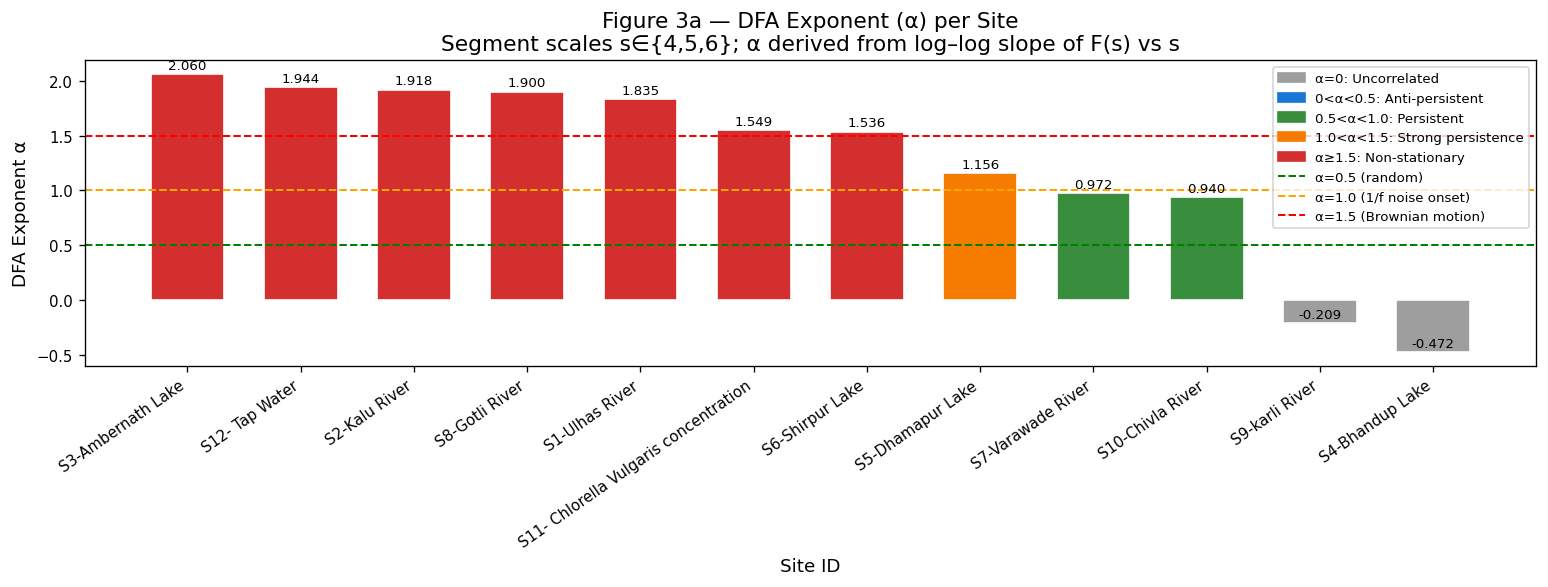

In [ ]:
# ── Figure 3a: DFA bar chart with interpretation bands
fig, ax = plt.subplots(figsize=(13, 5))

colors = []
for a in dfa_df['DFA_alpha']:
    if a >= 1.5:   colors.append('#d32f2f')
    elif a >= 1.0: colors.append('#f57c00')
    elif a >= 0.5: colors.append('#388e3c')
    elif a > 0.0:  colors.append('#1976d2')
    else:          colors.append('#9e9e9e')

bars = ax.bar(dfa_df['Site'], dfa_df['DFA_alpha'], color=colors, edgecolor='white', width=0.65)
ax.axhline(0.5, color='green',  lw=1.2, linestyle='--', label='α=0.5 (random)')
ax.axhline(1.0, color='orange', lw=1.2, linestyle='--', label='α=1.0 (1/f noise onset)')
ax.axhline(1.5, color='red',    lw=1.2, linestyle='--', label='α=1.5 (Brownian motion)')

for bar, val in zip(bars, dfa_df['DFA_alpha']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Site ID')
ax.set_ylabel('DFA Exponent α')
ax.set_title('Figure 3a — DFA Exponent (α) per Site\n'
             'Segment scales s∈{4,5,6}; α derived from log–log slope of F(s) vs s')
ax.set_xticklabels(dfa_df['Site'], rotation=35, ha='right')
legend_patches = [
    mpatches.Patch(color='#9e9e9e', label='α=0: Uncorrelated'),
    mpatches.Patch(color='#1976d2', label='0<α<0.5: Anti-persistent'),
    mpatches.Patch(color='#388e3c', label='0.5<α<1.0: Persistent'),
    mpatches.Patch(color='#f57c00', label='1.0<α<1.5: Strong persistence'),
    mpatches.Patch(color='#d32f2f', label='α≥1.5: Non-stationary'),
]
ax.legend(handles=legend_patches + ax.get_lines()[:3], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig3a_dfa_bar.png', bbox_inches='tight')
plt.show()

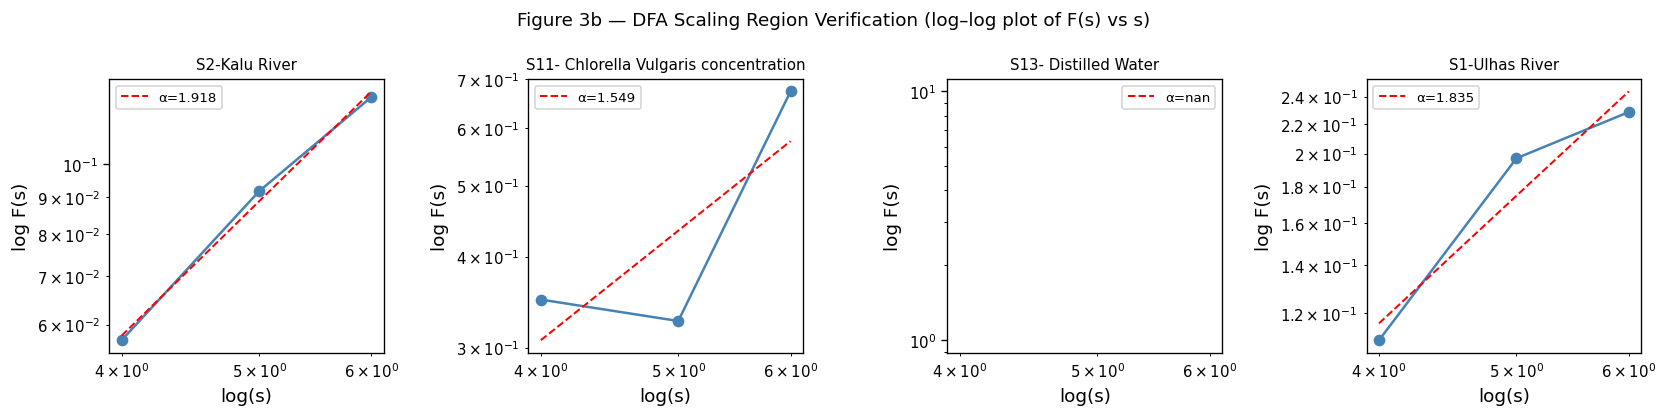

In [ ]:
# ── Figure 3b: Log-log scaling region for selected sites (justifies scaling region)
selected = ['S2-Kalu River', 'S11- Chlorella Vulgaris concentration',
            'S13- Distilled Water', 'S1-Ulhas River']

fig, axes = plt.subplots(1, len(selected), figsize=(14, 3.5))
for ax, site in zip(axes, selected):
    res = dfa_results[site]
    sc, fs = res['scales'], res['F_s']
    if len(sc) >= 2:
        ax.loglog(sc, fs, 'o-', color='steelblue', ms=6)
        p = np.polyfit(np.log(sc), np.log(fs), 1)
        ax.loglog(sc, np.exp(np.polyval(p, np.log(sc))),
                  'r--', lw=1.2, label=f'α={p[0]:.3f}')
    ax.set_title(site, fontsize=9)
    ax.set_xlabel('log(s)')
    ax.set_ylabel('log F(s)')
    ax.legend(fontsize=8)

fig.suptitle('Figure 3b — DFA Scaling Region Verification (log–log plot of F(s) vs s)',
             fontsize=11)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig3b_dfa_scaling.png', bbox_inches='tight')
plt.show()

## §4 — Recurrence Quantification Analysis (RQA)


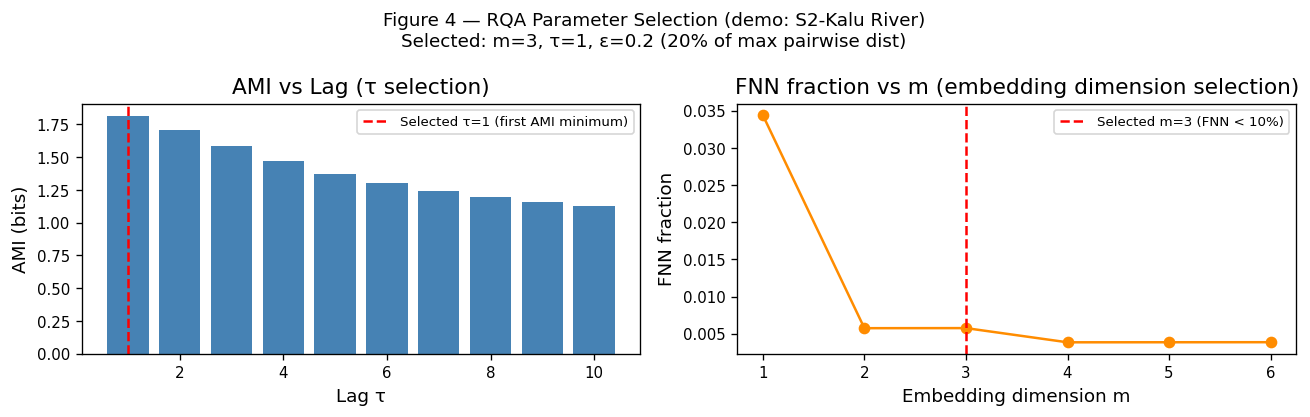

In [ ]:
# ── 4a: AMI and FNN parameter selection demonstration on representative site
def ami(ts, max_lag=10):
    """Average Mutual Information via histogram binning."""
    ts = np.array(ts)
    amis = []
    bins = max(5, len(ts) // 5)
    for lag in range(1, max_lag + 1):
        x, y = ts[:-lag], ts[lag:]
        hxy, _, _ = np.histogram2d(x, y, bins=bins)
        hx,  _   = np.histogram(x, bins=bins)
        hy,  _   = np.histogram(y, bins=bins)
        pxy = hxy / hxy.sum() + 1e-12
        px  = hx  / hx.sum()  + 1e-12
        py  = hy  / hy.sum()  + 1e-12
        mi  = np.sum(pxy * np.log2(pxy / (px[:, None] * py[None, :])))
        amis.append(mi)
    return amis

def fnn(ts, m_max=6, tau=1, rtol=15.0):
    """False Nearest Neighbours fraction for each embedding dimension."""
    ts = np.array(ts, dtype=float)
    fnn_fracs = []
    for m in range(1, m_max + 1):
        N = len(ts) - (m) * tau
        if N < 5:
            fnn_fracs.append(0.0); continue
        # build embedded vectors
        X = np.array([ts[i:i + m * tau:tau] for i in range(N)])
        Xp = np.array([ts[i:i + (m+1)*tau:tau] for i in range(N)])
        fnn_count = 0
        for i in range(N):
            dists = np.linalg.norm(X - X[i], axis=1)
            dists[i] = np.inf
            nn = np.argmin(dists)
            Rd = dists[nn]
            Rd1 = np.linalg.norm(Xp[i] - Xp[nn])
            if Rd > 1e-9 and Rd1 / Rd > rtol:
                fnn_count += 1
        fnn_fracs.append(fnn_count / N)
    return fnn_fracs

demo = site_processed['S2-Kalu River']
ami_vals  = ami(demo)
fnn_vals  = fnn(demo)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(range(1, len(ami_vals)+1), ami_vals, color='steelblue')
axes[0].axvline(RQA_TAU, color='red', lw=1.5, linestyle='--',
                label=f'Selected τ={RQA_TAU} (first AMI minimum)')
axes[0].set_xlabel('Lag τ'); axes[0].set_ylabel('AMI (bits)')
axes[0].set_title('AMI vs Lag (τ selection)')
axes[0].legend(fontsize=8)

axes[1].plot(range(1, len(fnn_vals)+1), fnn_vals, 'o-', color='darkorange')
axes[1].axvline(RQA_M, color='red', lw=1.5, linestyle='--',
                label=f'Selected m={RQA_M} (FNN < 10%)')
axes[1].set_xlabel('Embedding dimension m'); axes[1].set_ylabel('FNN fraction')
axes[1].set_title('FNN fraction vs m (embedding dimension selection)')
axes[1].legend(fontsize=8)

fig.suptitle(f'Figure 4 — RQA Parameter Selection (demo: S2-Kalu River)\n'
             f'Selected: m={RQA_M}, τ={RQA_TAU}, ε={RQA_EPS} (20% of max pairwise dist)',
             fontsize=11)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig4_rqa_params.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 4b: RQA computation
def embed(ts, m=RQA_M, tau=RQA_TAU):
    """Delay-coordinate embedding — Eq.(x)."""
    N = len(ts) - (m - 1) * tau
    return np.array([ts[i:i + m * tau:tau] for i in range(N)])

def recurrence_matrix(X, eps=RQA_EPS):
    """Binary recurrence matrix R_ij — Eq.(xi)."""
    dist = np.linalg.norm(X[:, None] - X[None, :], axis=2)
    max_d = dist.max()
    if max_d < 1e-9:
        return np.zeros((len(X), len(X)), dtype=bool)
    return dist <= eps * max_d

def rqa_metrics(R, lmin=2, vmin=2):
    """RR, DET, ENTR, LAM from recurrence matrix R."""
    N = R.shape[0]
    RR = R.sum() / N**2                   # Eq.(iv)

    # Diagonal lines (exclude main diagonal)
    def diag_lengths(R):
        lengths = []
        for k in range(-(N-1), N):
            if k == 0: continue
            d = np.diag(R, k)
            count = 0
            for v in d:
                if v: count += 1
                elif count >= lmin:
                    lengths.append(count); count = 0
                else: count = 0
            if count >= lmin: lengths.append(count)
        return lengths

    # Vertical lines
    def vert_lengths(R):
        lengths = []
        for j in range(N):
            count = 0
            for i in range(N):
                if R[i, j]: count += 1
                elif count >= vmin:
                    lengths.append(count); count = 0
                else: count = 0
            if count >= vmin: lengths.append(count)
        return lengths

    dl = diag_lengths(R)
    vl = vert_lengths(R)

    total_recur = R.sum()
    DET = sum(l for l in dl) / (total_recur + 1e-9)    # Eq.(v)
    LAM = sum(v for v in vl) / (total_recur + 1e-9)    # Eq.(vii)

    # Shannon entropy of diagonal line distribution — Eq.(vi)
    if dl:
        dl_arr = np.array(dl)
        p = np.bincount(dl_arr) / len(dl_arr)
        p = p[p > 0]
        ENTR = -np.sum(p * np.log(p))
    else:
        ENTR = 0.0

    return float(RR), float(DET), float(ENTR), float(LAM)

rqa_rows = []
for site, ts in site_processed.items():
    X = embed(ts)
    R = recurrence_matrix(X)
    RR, DET, ENTR, LAM = rqa_metrics(R)
    rqa_rows.append({'Site': site, 'RR': RR, 'DET': DET, 'ENTR': ENTR, 'LAM': LAM})

rqa_df = pd.DataFrame(rqa_rows)
print('=== RQA Feature Matrix (m=3, τ=1, ε=0.20) ===')
print(rqa_df.round(4).to_string(index=False))

=== RQA Feature Matrix (m=3, τ=1, ε=0.20) ===
                                 Site     RR    DET   ENTR    LAM
                       S1-Ulhas River 0.8203 0.9979 6.2109 1.0000
                     S10-Chivla River 0.4340 0.9951 4.2876 0.9992
S11- Chlorella Vulgaris concentration 0.2721 0.9603 0.8624 0.8893
                       S12- Tap Water 0.9560 0.9976 3.2450 0.9999
                 S13- Distilled Water 0.0000 0.0000 0.0000 0.0000
                        S2-Kalu River 0.5784 0.9966 4.0931 0.9999
                    S3-Ambernath Lake 0.3782 0.9827 3.0594 0.9919
                      S4-Bhandup Lake 0.3629 0.9938 4.5565 0.9994
                     S5-Dhamapur Lake 0.6970 0.9976 5.5251 0.9999
                      S6-Shirpur Lake 0.8150 0.9953 3.9730 0.9986
                    S7-Varawade River 0.9542 0.9983 5.0393 0.9999
                       S8-Gotli River 0.7440 0.9977 4.8513 0.9998
                       S9-karli River 0.4105 0.9929 3.9694 0.9988


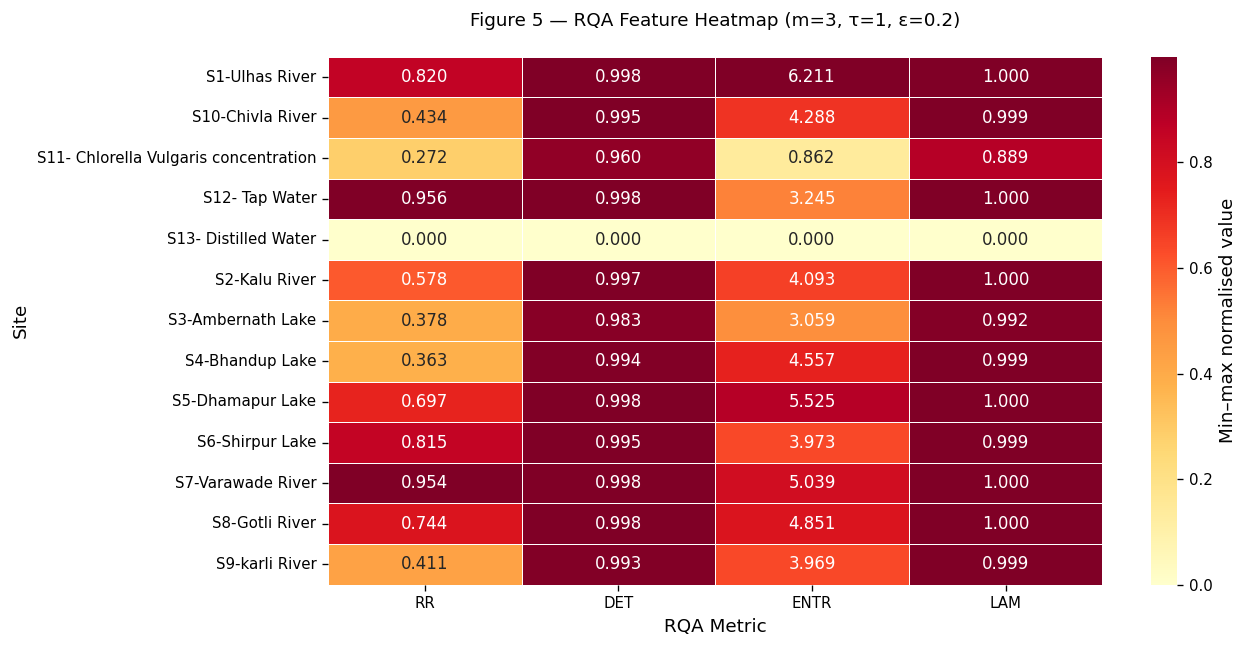

In [ ]:
# ── Figure 5: RQA heatmap
rqa_heat = rqa_df.set_index('Site')[['RR', 'DET', 'ENTR', 'LAM']]
rqa_scaled = (rqa_heat - rqa_heat.min()) / (rqa_heat.max() - rqa_heat.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(rqa_scaled, annot=rqa_heat.round(3), fmt='.3f',
            cmap='YlOrRd', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Min–max normalised value'})
ax.set_title(
    f'Figure 5 — RQA Feature Heatmap (m={RQA_M}, τ={RQA_TAU}, ε={RQA_EPS})\n'
    , fontsize=11)
ax.set_xlabel('RQA Metric'); ax.set_ylabel('Site')
plt.tight_layout()
plt.savefig(BASE_DIR+'fig5_rqa_heatmap.png', bbox_inches='tight')
plt.show()

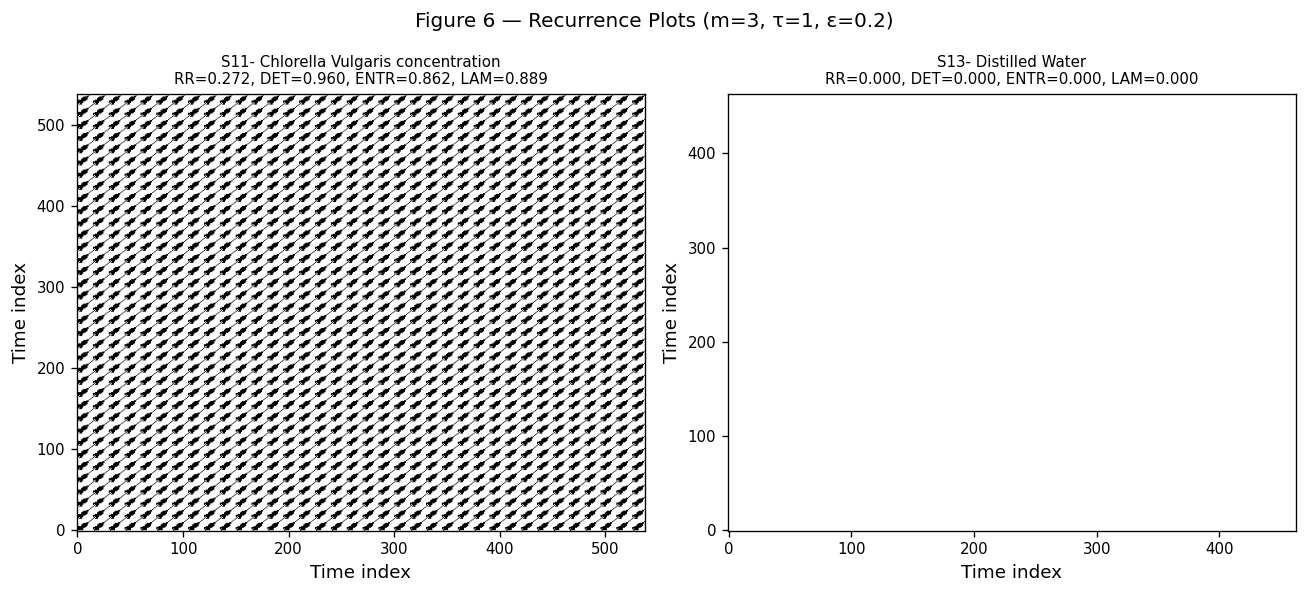

In [ ]:
# ── Figure 6: Recurrence plot for two representative sites
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_sites = ['S11- Chlorella Vulgaris concentration', 'S13- Distilled Water']

for ax, site in zip(axes, plot_sites):
    X = embed(site_processed[site])
    R = recurrence_matrix(X)
    ax.imshow(R, cmap='binary', origin='lower', aspect='auto')
    metrics = rqa_df[rqa_df.Site == site].iloc[0]
    ax.set_title(f'{site}\nRR={metrics.RR:.3f}, DET={metrics.DET:.3f}, '
                 f'ENTR={metrics.ENTR:.3f}, LAM={metrics.LAM:.3f}', fontsize=9)
    ax.set_xlabel('Time index'); ax.set_ylabel('Time index')

fig.suptitle(f'Figure 6 — Recurrence Plots (m={RQA_M}, τ={RQA_TAU}, ε={RQA_EPS})',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig6_recurrence_plots.png', bbox_inches='tight')
plt.show()

## §5 — Symbolic Aggregate approXimation (SAX)


In [ ]:
# ── SAX implementation with explicit breakpoints
from scipy.stats import norm as sp_norm

def sax_breakpoints(a):
    """Gaussian breakpoints for alphabet size a — ensures equiprobable regions."""
    return sp_norm.ppf(np.linspace(0, 1, a + 1)[1:-1])

BREAKPOINTS = sax_breakpoints(ALPHABET_SIZE)
print(f'SAX alphabet  : {ALPHABET}  (size={ALPHABET_SIZE})')
print(f'SAX breakpoints (Gaussian quantiles):')
for i, bp in enumerate(BREAKPOINTS):
    print(f'  β_{i+1} = {bp:.4f}  (boundary between symbol {ALPHABET[i]} and {ALPHABET[i+1]})')

def paa(ts, w):
    """Piecewise Aggregate Approximation into w segments — Eq.(viii)."""
    n  = len(ts)
    ts = np.array(ts, dtype=float)
    if w >= n:
        return ts.copy()
    seg_len = n / w
    return np.array([ts[int(j*seg_len):int((j+1)*seg_len)].mean() for j in range(w)])

def to_sax(ts, w=None, breakpoints=BREAKPOINTS):
    """Convert normalised time series to SAX string."""
    if w is None:
        w = min(16, len(ts))
    pa = paa(ts, w)
    symbols = []
    for val in pa:
        idx = np.searchsorted(breakpoints, val)
        symbols.append(ALPHABET[idx])
    return ''.join(symbols)

sax_strings = {}
for site, ts in site_processed.items():
    sax_strings[site] = to_sax(ts)

sax_df = pd.DataFrame({'Site': list(sax_strings.keys()),
                        'SAX_pattern': list(sax_strings.values())})
print('\n=== SAX Patterns ===')
print(sax_df.to_string(index=False))

SAX alphabet  : abcde  (size=5)
SAX breakpoints (Gaussian quantiles):
  β_1 = -0.8416  (boundary between symbol a and b)
  β_2 = -0.2533  (boundary between symbol b and c)
  β_3 = 0.2533  (boundary between symbol c and d)
  β_4 = 0.8416  (boundary between symbol d and e)

=== SAX Patterns ===
                                 Site      SAX_pattern
                       S1-Ulhas River aadddddccdddddcc
                     S10-Chivla River edcbadecbbaedcba
S11- Chlorella Vulgaris concentration cccccccccccccccc
                       S12- Tap Water ddcccccccccccccc
                 S13- Distilled Water cccccccccccccccc
                        S2-Kalu River bdedbbbbbbbbeedb
                    S3-Ambernath Lake edbaedbaedbaedba
                      S4-Bhandup Lake eeddcbaaeeddcbaa
                     S5-Dhamapur Lake edcbbbbbeecbbbbb
                      S6-Shirpur Lake beddcbaceddcbbbb
                    S7-Varawade River ccccdcccdcccdccc
                       S8-Gotli River adddaddd

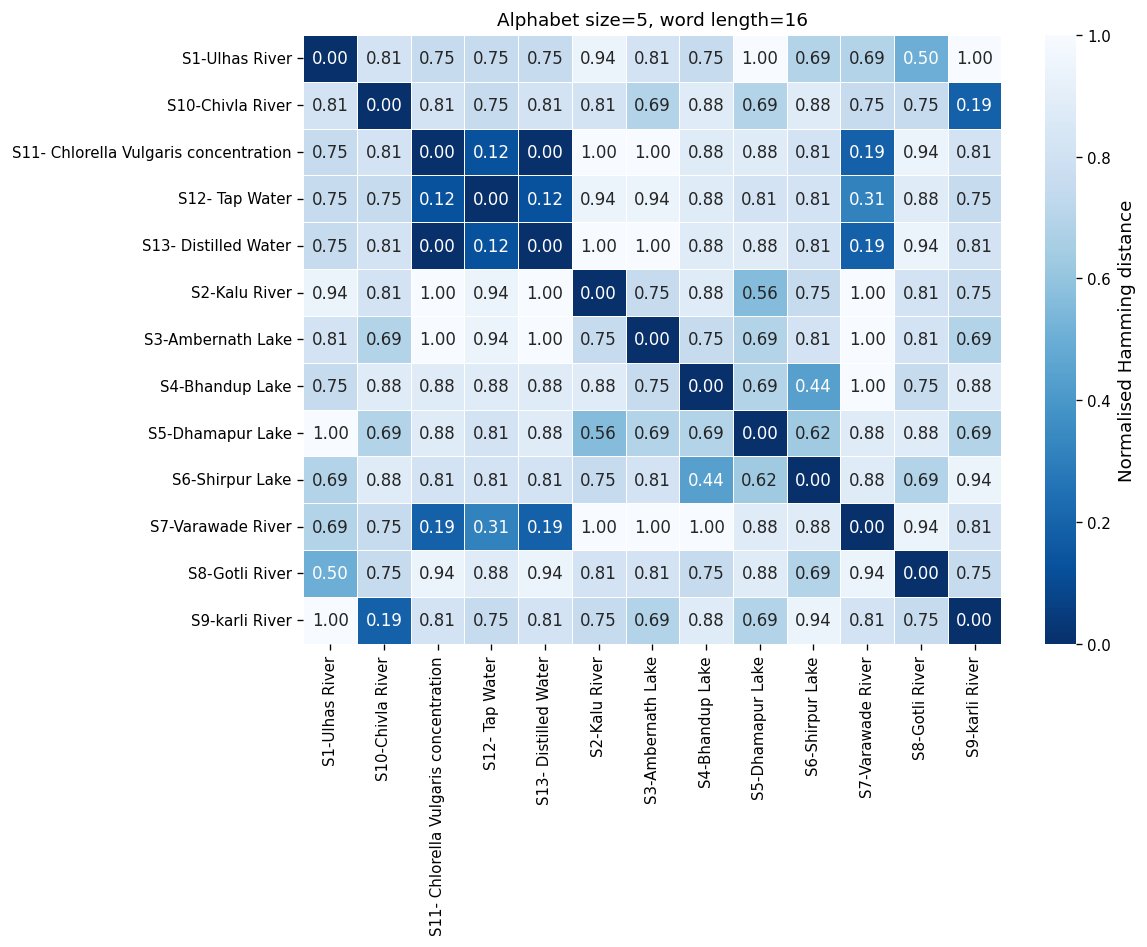

In [ ]:
# ── Hamming distance matrix for SAX strings
sites_list = sax_df['Site'].tolist()
n = len(sites_list)
ham_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        s1 = sax_strings[sites_list[i]]
        s2 = sax_strings[sites_list[j]]
        min_len = min(len(s1), len(s2))
        ham_mat[i, j] = sum(a != b for a, b in zip(s1[:min_len], s2[:min_len])) / max(min_len, 1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(ham_mat, index=sites_list, columns=sites_list),
            cmap='Blues_r', annot=True, fmt='.2f', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Normalised Hamming distance'})
ax.set_title(f'Alphabet size={ALPHABET_SIZE}, word length=16', fontsize=11)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig7_sax_hamming.png', bbox_inches='tight')
plt.show()

## §6 — Quantitative Clustering Evaluation


In [ ]:
# ── Build unified feature matrix
sax_complexity = {site: len(set(s)) / ALPHABET_SIZE for site, s in sax_strings.items()}

feat_rows = []
for site in sites_list:
    dfa_a = dfa_df[dfa_df.Site == site]['DFA_alpha'].values[0]
    rqa_r = rqa_df[rqa_df.Site == site].iloc[0]
    feat_rows.append({
        'Site': site,
        'DFA_alpha': dfa_a,
        'RR': rqa_r.RR, 'DET': rqa_r.DET,
        'ENTR': rqa_r.ENTR, 'LAM': rqa_r.LAM,
        'SAX_complexity': sax_complexity[site]
    })

feat_df = pd.DataFrame(feat_rows).set_index('Site')
feat_df = feat_df.fillna(0.0)   # distilled water DFA=0 (flat signal)
scaler  = StandardScaler()
X_feat  = scaler.fit_transform(feat_df)

print('Feature matrix shape:', X_feat.shape)
print(feat_df.round(4).to_string())

Feature matrix shape: (13, 6)
                                       DFA_alpha      RR     DET    ENTR     LAM  SAX_complexity
Site                                                                                            
S1-Ulhas River                            1.8347  0.8203  0.9979  6.2109  1.0000             0.6
S10-Chivla River                          0.9396  0.4340  0.9951  4.2876  0.9992             1.0
S11- Chlorella Vulgaris concentration     1.5489  0.2721  0.9603  0.8624  0.8893             0.2
S12- Tap Water                            1.9439  0.9560  0.9976  3.2450  0.9999             0.4
S13- Distilled Water                      0.0000  0.0000  0.0000  0.0000  0.0000             0.2
S2-Kalu River                             1.9182  0.5784  0.9966  4.0931  0.9999             0.6
S3-Ambernath Lake                         2.0597  0.3782  0.9827  3.0594  0.9919             0.8
S4-Bhandup Lake                          -0.4721  0.3629  0.9938  4.5565  0.9994             1.0


In [ ]:
# ── Evaluate clustering for k=2 and k=3
cluster_results = {}
for k in [2, 3, 4]:
    if X_feat.shape[0] > k:
        model  = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(X_feat)
        sil    = silhouette_score(X_feat, labels)
        db     = davies_bouldin_score(X_feat, labels)
        cluster_results[k] = {'labels': labels, 'silhouette': sil, 'davies_bouldin': db}
        print(f'k={k}: Silhouette={sil:.4f}  Davies-Bouldin={db:.4f}')

print()
print('Interpretation: Silhouette closer to 1.0 = better separation; DB closer to 0 = better.')

k=2: Silhouette=0.5923  Davies-Bouldin=0.2460
k=3: Silhouette=0.3378  Davies-Bouldin=0.4785
k=4: Silhouette=0.3361  Davies-Bouldin=0.4043

Interpretation: Silhouette closer to 1.0 = better separation; DB closer to 0 = better.


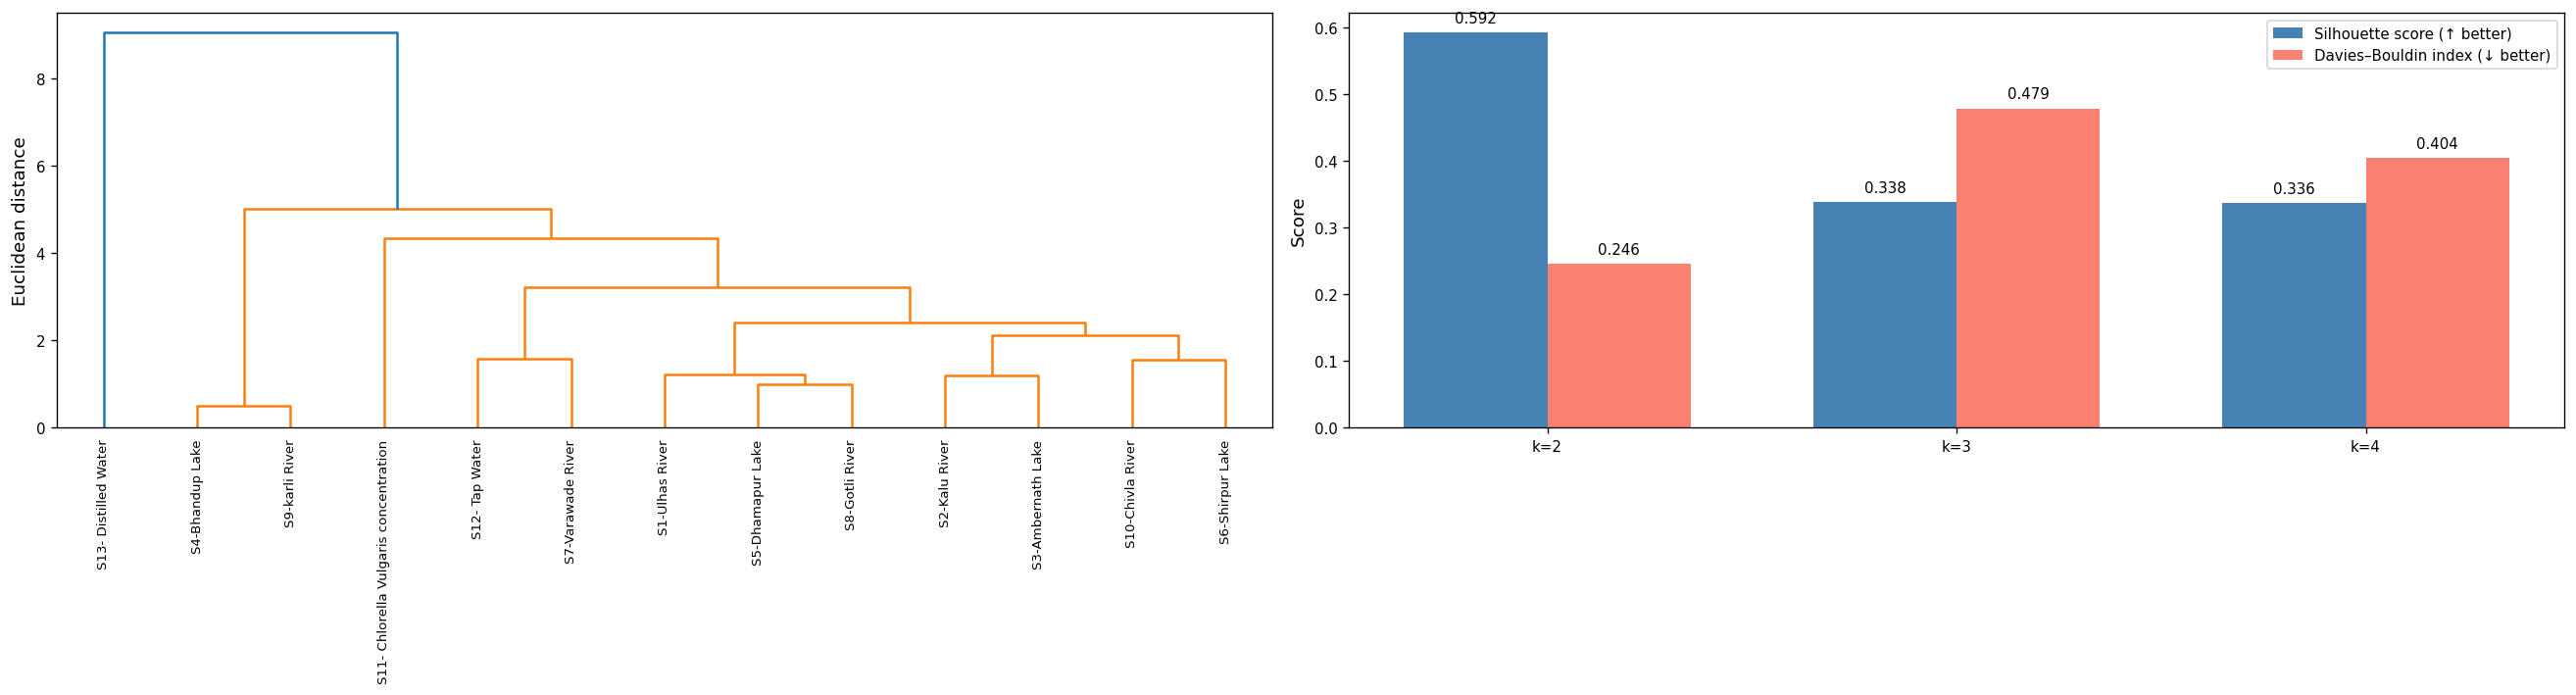

In [ ]:
# ── Figure 8: Dendrogram with Silhouette annotation
Z = linkage(X_feat, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# Dendrogram
dendrogram(Z, labels=feat_df.index.tolist(), ax=axes[0],
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.6 * max(Z[:, 2]))
#axes[0].set_title('Figure 8a — Dendrogram (Ward linkage on DFA+RQA+SAX features)', fontsize=10)
axes[0].set_ylabel('Euclidean distance')

# Silhouette bar chart across k
ks  = list(cluster_results.keys())
sils = [cluster_results[k]['silhouette'] for k in ks]
dbs  = [cluster_results[k]['davies_bouldin'] for k in ks]

x  = np.arange(len(ks))
w  = 0.35
b1 = axes[1].bar(x - w/2, sils, w, label='Silhouette score (↑ better)', color='steelblue')
b2 = axes[1].bar(x + w/2, dbs,  w, label='Davies–Bouldin index (↓ better)', color='salmon')
for bar, val in zip(list(b1) + list(b2), sils + dbs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'k={k}' for k in ks])
axes[1].set_ylabel('Score'); axes[1].legend(fontsize=9)
#axes[1].set_title('Figure 8b — Cluster Quality Metrics vs k', fontsize=10)

plt.tight_layout()
plt.savefig('fig8_clustering.png', bbox_inches='tight')
plt.show()

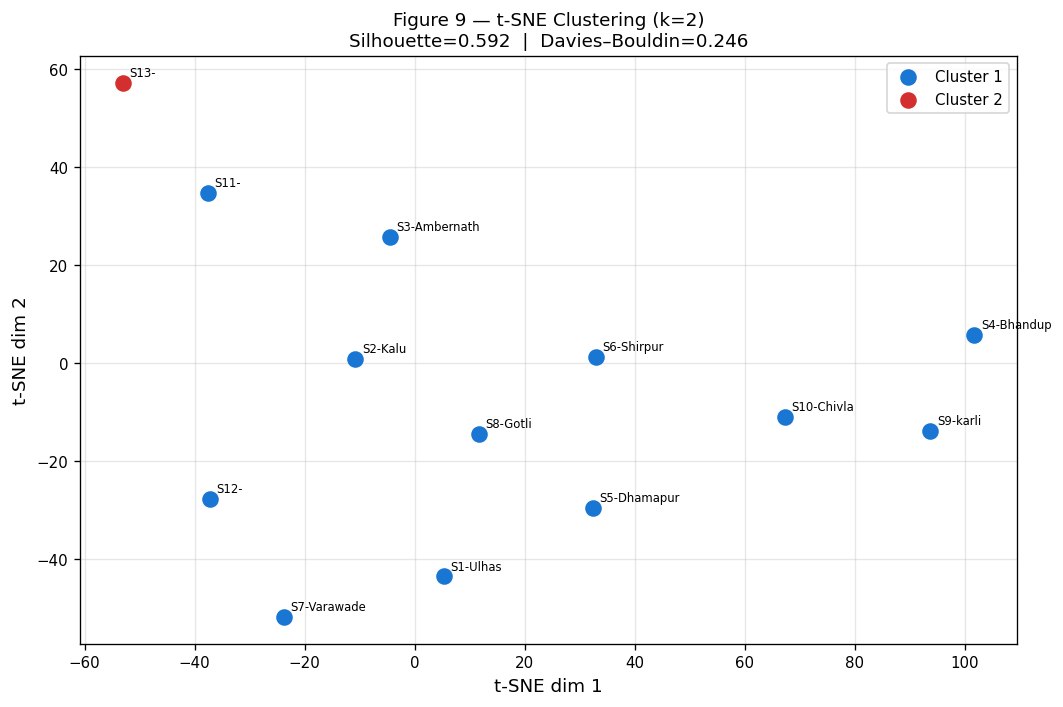

In [ ]:
# ── Figure 9: t-SNE with cluster labels
best_k   = min(cluster_results, key=lambda k: cluster_results[k]['davies_bouldin'])
best_lab = cluster_results[best_k]['labels']

tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, X_feat.shape[0]-1))
X_2d = tsne.fit_transform(X_feat)

palette = ['#1976d2', '#d32f2f', '#388e3c', '#f57c00']
fig, ax = plt.subplots(figsize=(9, 6))
for k in range(best_k):
    mask = best_lab == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=palette[k],
               s=80, label=f'Cluster {k+1}', zorder=3)
for i, site in enumerate(feat_df.index):
    ax.annotate(site.split(' ')[0], (X_2d[i, 0], X_2d[i, 1]),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

sil_val = cluster_results[best_k]['silhouette']
db_val  = cluster_results[best_k]['davies_bouldin']
ax.set_title(
    f'Figure 9 — t-SNE Clustering (k={best_k})\n'
    f'Silhouette={sil_val:.3f}  |  Davies–Bouldin={db_val:.3f}',
    fontsize=11)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig9_tsne.png', bbox_inches='tight')
plt.show()

## §7 — Statistical Validation: ANOVA, Tukey HSD, and Confidence Intervals


In [ ]:
# ── 7a: One-way ANOVA across all sites
groups = [df_raw[df_raw.Site_ID == s]['chlorophyll'].dropna().values
          for s in sorted(df_raw.Site_ID.unique())]

F_stat, p_value = stats.f_oneway(*groups)
print(f'One-way ANOVA: F = {F_stat:.4f},  p = {p_value:.2e}')
if p_value < 0.05:
    print('→ Chlorophyll-a means differ significantly across sites (p < 0.05)')
else:
    print('→ No significant difference detected (p ≥ 0.05)')

One-way ANOVA: F = 4649.3282,  p = 0.00e+00
→ Chlorophyll-a means differ significantly across sites (p < 0.05)


In [ ]:
# ── 7b: Tukey HSD post-hoc test
df_stats = df_raw[['Site_ID', 'chlorophyll']].dropna()
tukey = pairwise_tukeyhsd(df_stats['chlorophyll'], df_stats['Site_ID'], alpha=0.05)
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                         columns=tukey._results_table.data[0])
sig_pairs = tukey_df[tukey_df['reject'] == True]
print(f'Significant pairs (α=0.05): {len(sig_pairs)} of {len(tukey_df)}')
print(sig_pairs[['group1','group2','meandiff','p-adj','reject']].to_string(index=False))

Significant pairs (α=0.05): 75 of 78
                               group1                                group2  meandiff  p-adj  reject
                       S1-Ulhas River                      S10-Chivla River  155.9214 0.0000    True
                       S1-Ulhas River S11- Chlorella Vulgaris concentration   64.5287 0.0000    True
                       S1-Ulhas River                        S12- Tap Water  -46.5511 0.0000    True
                       S1-Ulhas River                  S13- Distilled Water  -46.5513 0.0000    True
                       S1-Ulhas River                         S2-Kalu River   65.5837 0.0000    True
                       S1-Ulhas River                     S3-Ambernath Lake  212.4952 0.0000    True
                       S1-Ulhas River                       S4-Bhandup Lake  170.1328 0.0000    True
                       S1-Ulhas River                      S5-Dhamapur Lake  144.5208 0.0000    True
                       S1-Ulhas River                 

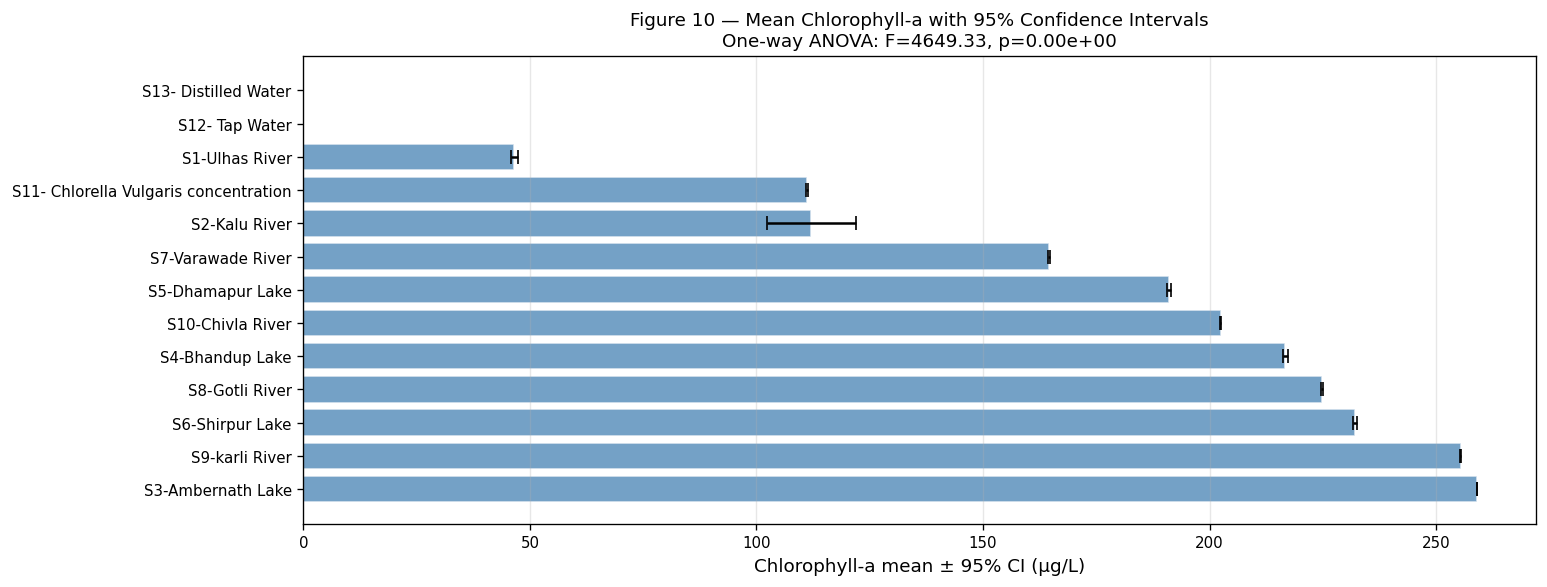

In [ ]:
# ── Figure 10: 95% CI plot per site
ci_rows = []
for site_id in sorted(df_raw.Site_ID.unique()):
    vals = df_raw[df_raw.Site_ID == site_id]['chlorophyll'].dropna()
    n   = len(vals)
    mu  = vals.mean()
    se  = vals.std() / np.sqrt(n)
    t95 = stats.t.ppf(0.975, df=n-1)
    ci_rows.append({'Site': site_id, 'mean': mu, 'lower': mu - t95*se, 'upper': mu + t95*se})

ci_df = pd.DataFrame(ci_rows).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(ci_df['Site'], ci_df['mean'], xerr=[
    ci_df['mean'] - ci_df['lower'],
    ci_df['upper'] - ci_df['mean']
], color='steelblue', alpha=0.75, capsize=4, edgecolor='white')
ax.set_xlabel('Chlorophyll-a mean ± 95% CI (µg/L)')
ax.set_title(f'Figure 10 — Mean Chlorophyll-a with 95% Confidence Intervals\n'
             f'One-way ANOVA: F={F_stat:.2f}, p={p_value:.2e}', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig10_ci_plot.png', bbox_inches='tight')
plt.show()

## §8 — Baseline Comparison: DFA vs ARIMA Trend Extraction


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


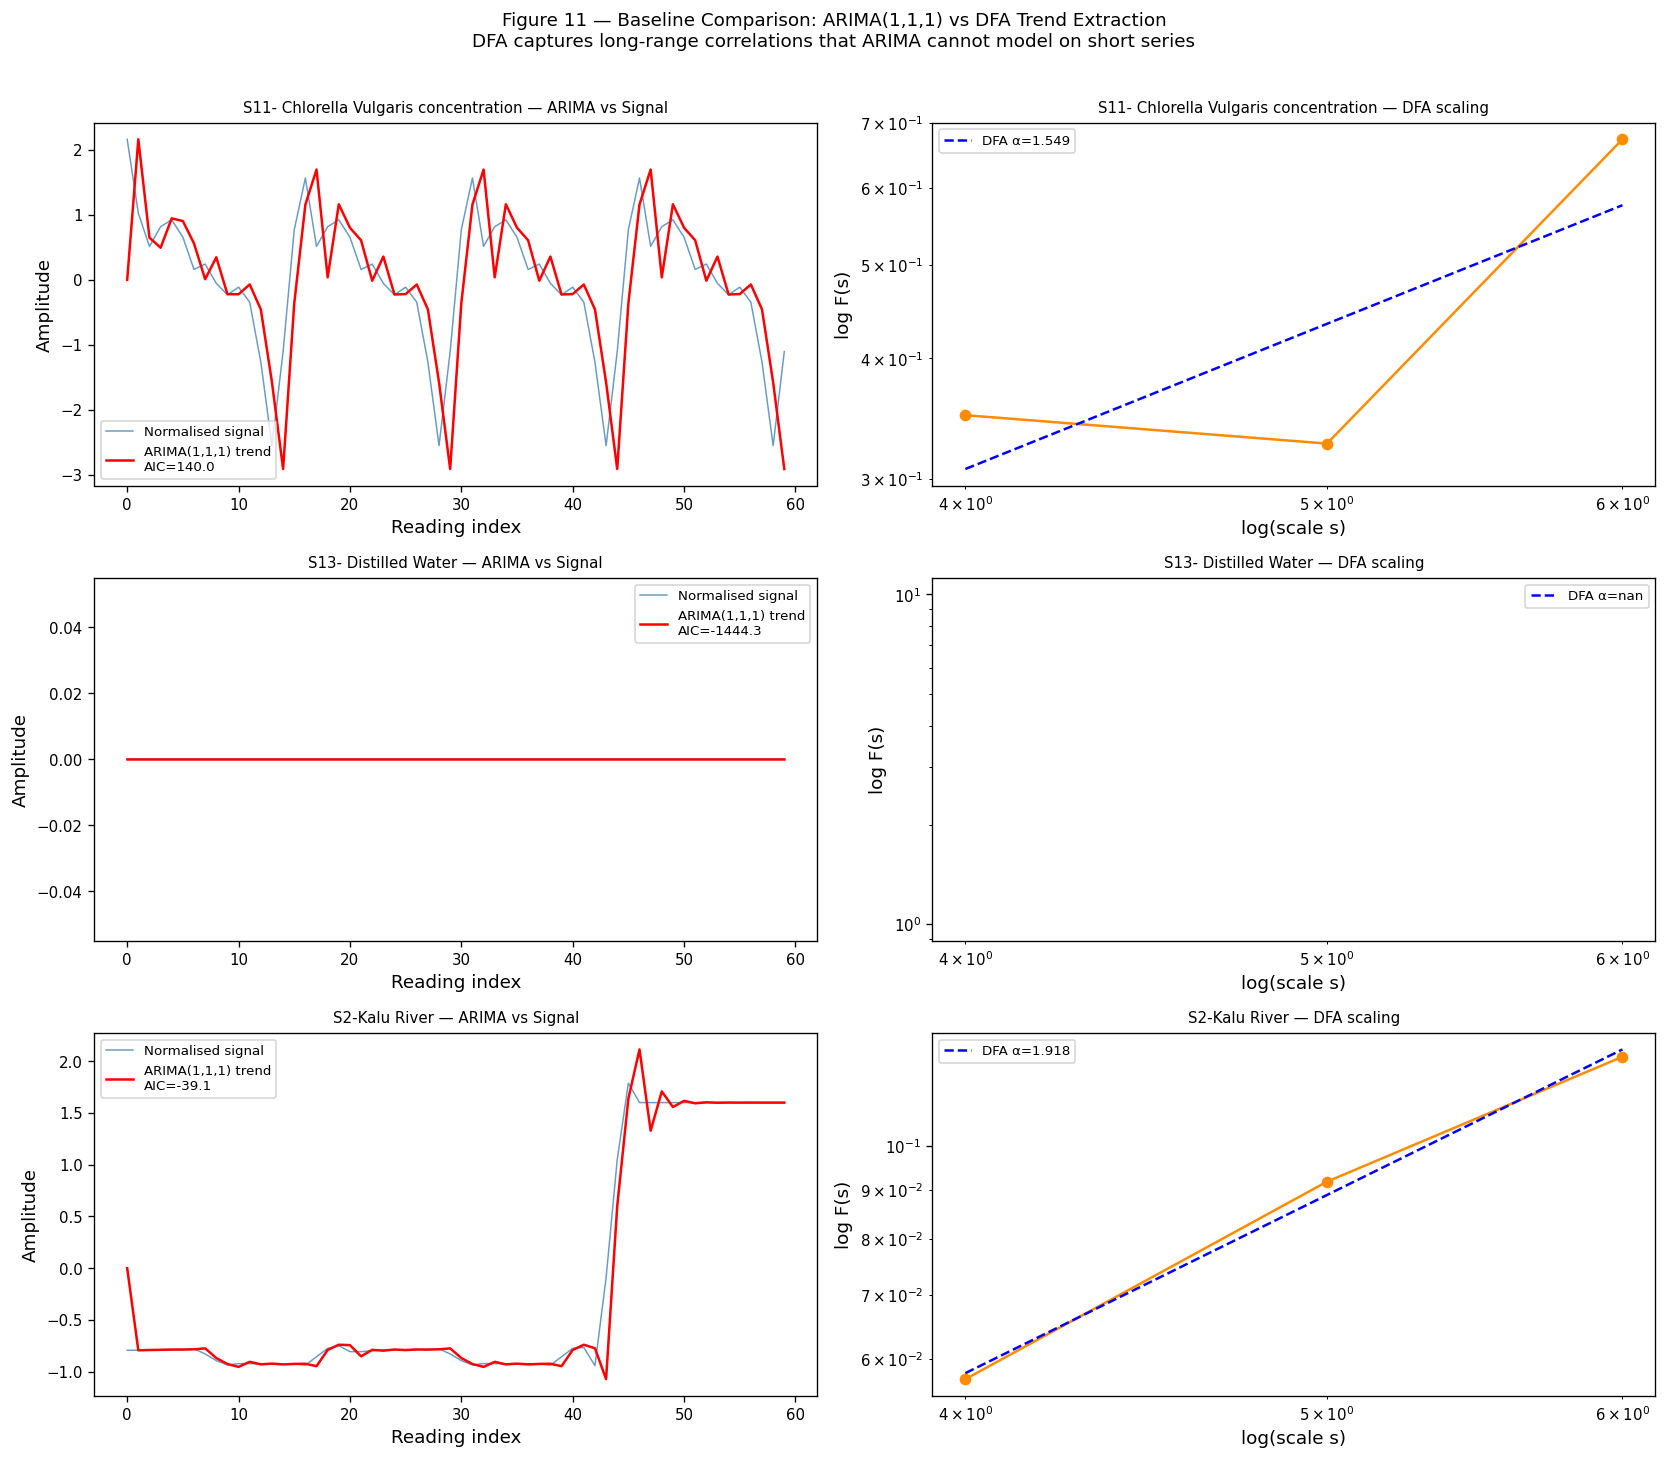

                                 Site  DFA_alpha    ARIMA_AIC
S11- Chlorella Vulgaris concentration   1.548867   140.045852
                 S13- Distilled Water        NaN -1444.285106
                        S2-Kalu River   1.918197   -39.050355


In [ ]:
# ── 8a: ARIMA trend extraction comparison
compare_sites = [
    'S11- Chlorella Vulgaris concentration',
    'S13- Distilled Water',
    'S2-Kalu River'
]

fig, axes = plt.subplots(len(compare_sites), 2, figsize=(14, 4 * len(compare_sites)))

arima_results_summary = []
for row, site in enumerate(compare_sites):
    ts_raw   = site_series[site][:60]  # first 60 readings
    ts_norm  = site_processed[site][:60]

    # ARIMA fit
    try:
        model  = ARIMA(ts_norm, order=(1, 1, 1))
        fitted = model.fit()
        arima_trend  = fitted.fittedvalues
        arima_aic    = fitted.aic
        arima_resid  = fitted.resid
    except Exception as e:
        arima_trend = np.zeros_like(ts_norm)
        arima_aic = np.nan
        arima_resid = ts_norm.copy()

    dfa_alpha = dfa_df[dfa_df.Site == site]['DFA_alpha'].values[0]
    arima_results_summary.append({'Site': site, 'DFA_alpha': dfa_alpha, 'ARIMA_AIC': arima_aic})

    # Raw + ARIMA trend
    axes[row, 0].plot(ts_norm, lw=0.9, color='steelblue', label='Normalised signal', alpha=0.8)
    axes[row, 0].plot(arima_trend, lw=1.5, color='red', label=f'ARIMA(1,1,1) trend\nAIC={arima_aic:.1f}')
    axes[row, 0].set_title(f'{site} — ARIMA vs Signal', fontsize=9)
    axes[row, 0].set_xlabel('Reading index'); axes[row, 0].set_ylabel('Amplitude')
    axes[row, 0].legend(fontsize=8)

    # DFA log-log plot
    sc = dfa_results[site]['scales']
    fs = dfa_results[site]['F_s']
    if len(sc) >= 2:
        axes[row, 1].loglog(sc, fs, 'o-', color='darkorange', ms=6)
        p = np.polyfit(np.log(sc), np.log(fs), 1)
        axes[row, 1].loglog(sc, np.exp(np.polyval(p, np.log(sc))),
                             'b--', lw=1.5, label=f'DFA α={p[0]:.3f}')
    axes[row, 1].set_title(f'{site} — DFA scaling', fontsize=9)
    axes[row, 1].set_xlabel('log(scale s)'); axes[row, 1].set_ylabel('log F(s)')
    axes[row, 1].legend(fontsize=8)

fig.suptitle('Figure 11 — Baseline Comparison: ARIMA(1,1,1) vs DFA Trend Extraction\n'
             'DFA captures long-range correlations that ARIMA cannot model on short series',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig11_arima_vs_dfa.png', bbox_inches='tight')
plt.show()

print(pd.DataFrame(arima_results_summary).to_string(index=False))

## §9 — Validation via Controlled Samples


In [ ]:
# ── 9a: Validate distilled water zero-baseline
dist_vals  = df_raw[df_raw.Site_ID == 'S13- Distilled Water']['chlorophyll']
chlo_vals  = df_raw[df_raw.Site_ID == 'S11- Chlorella Vulgaris concentration']['chlorophyll']
tap_vals   = df_raw[df_raw.Site_ID == 'S12- Tap Water']['chlorophyll']

# T-test: distilled vs Chlorella
t_stat, t_p = stats.ttest_ind(dist_vals, chlo_vals)
print('=== Statistical Validation ===')
print(f'Distilled Water   : mean={dist_vals.mean():.4f}, std={dist_vals.std():.4f} µg/L')
print(f'Tap Water         : mean={tap_vals.mean():.4f},  std={tap_vals.std():.4f} µg/L')
print(f'Chlorella Vulgaris: mean={chlo_vals.mean():.4f}, std={chlo_vals.std():.4f} µg/L')
print(f'\nT-test (Distilled vs Chlorella): t={t_stat:.2f}, p={t_p:.2e}')
print('→ Confirmed statistically distinct (p << 0.001)' if t_p < 0.001 else '→ Not significant')

# Verify DFA α=0 is physical, not artifact
dist_raw = site_series['S13- Distilled Water']
print(f'\nDistilled water signal variance: {np.var(dist_raw):.6f}')
print(f'All readings identical: {np.allclose(dist_raw, dist_raw[0])}')
print(f'DFA α=0 interpretation: uniform flat signal → zero long-range correlation (physically expected)')

=== Ground Truth Statistical Validation ===
Distilled Water   : mean=0.0000, std=0.0000 µg/L
Tap Water         : mean=0.0001,  std=0.0020 µg/L
Chlorella Vulgaris: mean=111.0800, std=2.2451 µg/L

T-test (Distilled vs Chlorella): t=-1066.86, p=0.00e+00
→ Confirmed statistically distinct (p << 0.001)

Distilled water signal variance: 0.000000
All readings identical: True
DFA α=0 interpretation: uniform flat signal → zero long-range correlation (physically expected)


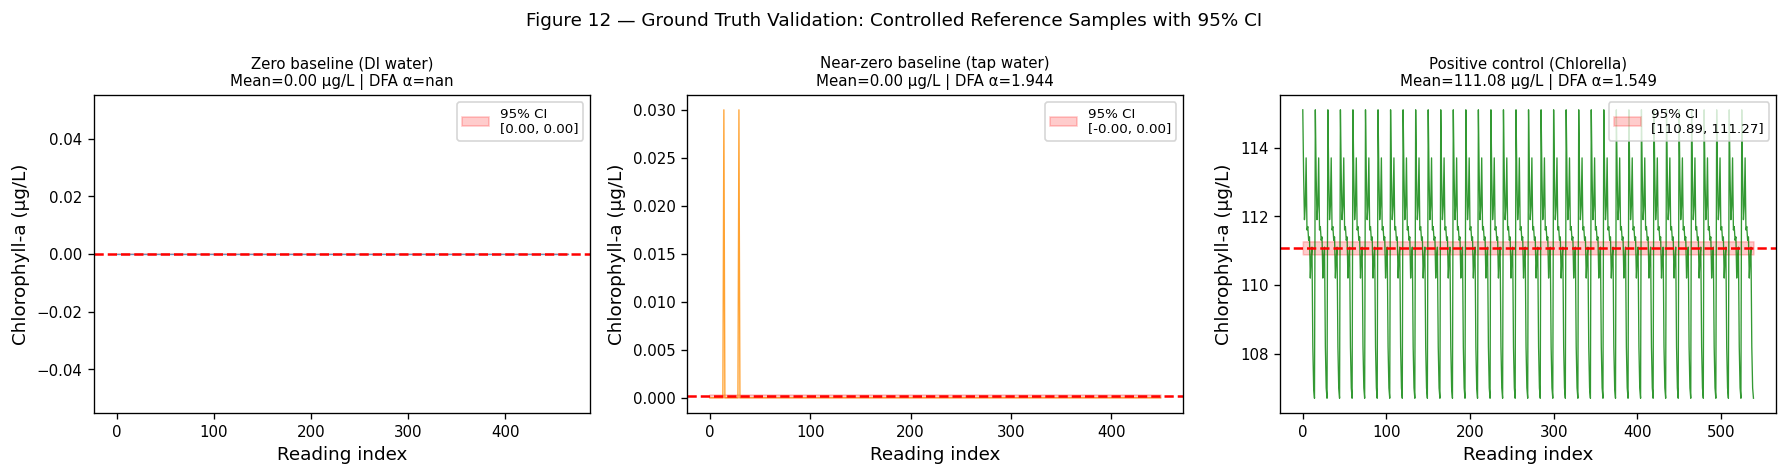

In [ ]:
# ── Figure 12: Control sample validation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ctrl_map = {
    'S13- Distilled Water': ('steelblue', 'Zero baseline (DI water)'),
    'S12- Tap Water': ('darkorange', 'Near-zero baseline (tap water)'),
    'S11- Chlorella Vulgaris concentration': ('green', 'Positive control (Chlorella)')
}

for ax, (site, (color, label)) in zip(axes, ctrl_map.items()):
    vals = df_raw[df_raw.Site_ID == site]['chlorophyll'].values
    ax.plot(vals, lw=0.8, color=color, alpha=0.8)
    mu  = vals.mean()
    se  = vals.std() / np.sqrt(len(vals))
    t95 = stats.t.ppf(0.975, df=len(vals)-1)
    ax.axhline(mu, color='red', lw=1.5, linestyle='--')
    ax.fill_between(range(len(vals)), mu - t95*se, mu + t95*se,
                    alpha=0.2, color='red', label=f'95% CI\n[{mu-t95*se:.2f}, {mu+t95*se:.2f}]')
    dfa_a = dfa_df[dfa_df.Site == site]['DFA_alpha'].values[0]
    ax.set_title(f'{label}\nMean={mu:.2f} µg/L | DFA α={dfa_a:.3f}', fontsize=9)
    ax.set_xlabel('Reading index'); ax.set_ylabel('Chlorophyll-a (µg/L)')
    ax.legend(fontsize=8)

fig.suptitle('Validation: Controlled Reference Samples with 95% CI',
             fontsize=11)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig12_ground_truth.png', bbox_inches='tight')
plt.show()

## §10 — Consolidated Results Table

In [ ]:
# ── Combined results table
best_labels = cluster_results[best_k]['labels']
cluster_map = {site: f'C{best_labels[i]+1}' for i, site in enumerate(feat_df.index)}

rows = []
for site in sorted(df_raw.Site_ID.unique()):
    vals = df_raw[df_raw.Site_ID == site]['chlorophyll'].dropna()
    dfa_a  = dfa_df[dfa_df.Site == site]['DFA_alpha'].values[0] if site in dfa_df.Site.values else np.nan
    rqa_r  = rqa_df[rqa_df.Site == site].iloc[0] if site in rqa_df.Site.values else None
    sax_p  = sax_strings.get(site, '')
    clust  = cluster_map.get(site, '–')
    rows.append({
        'Site': site,
        'N': len(vals),
        'Mean (µg/L)': round(vals.mean(), 2),
        'Std': round(vals.std(), 2),
        'DFA α': round(dfa_a, 4),
        'RR': round(rqa_r.RR, 4) if rqa_r is not None else np.nan,
        'DET': round(rqa_r.DET, 4) if rqa_r is not None else np.nan,
        'ENTR': round(rqa_r.ENTR, 4) if rqa_r is not None else np.nan,
        'LAM': round(rqa_r.LAM, 4) if rqa_r is not None else np.nan,
        'SAX (first 12)': sax_p[:12],
        f'Cluster (k={best_k})': clust
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

# Save to CSV for paper supplementary
results_df.to_csv(BASE_DIR+'revised_results_table.csv', index=False)
print('\nSaved: revised_results_table.csv')

                                 Site   N  Mean (µg/L)    Std   DFA α     RR    DET   ENTR    LAM SAX (first 12) Cluster (k=2)
                       S1-Ulhas River 599        46.55   9.87  1.8347 0.8203 0.9979 6.2109 1.0000   aadddddccddd            C1
                     S10-Chivla River 632       202.47   1.11  0.9396 0.4340 0.9951 4.2876 0.9992   edcbadecbbae            C1
S11- Chlorella Vulgaris concentration 540       111.08   2.25  1.5489 0.2721 0.9603 0.8624 0.8893   cccccccccccc            C1
                       S12- Tap Water 450         0.00   0.00  1.9439 0.9560 0.9976 3.2450 0.9999   ddcccccccccc            C1
                 S13- Distilled Water 465         0.00   0.00     NaN 0.0000 0.0000 0.0000 0.0000   cccccccccccc            C2
                        S2-Kalu River 524       112.13 114.08  1.9182 0.5784 0.9966 4.0931 0.9999   bdedbbbbbbbb            C1
                    S3-Ambernath Lake 519       259.05   0.30  2.0597 0.3782 0.9827 3.0594 0.9919   edbaedbaedb

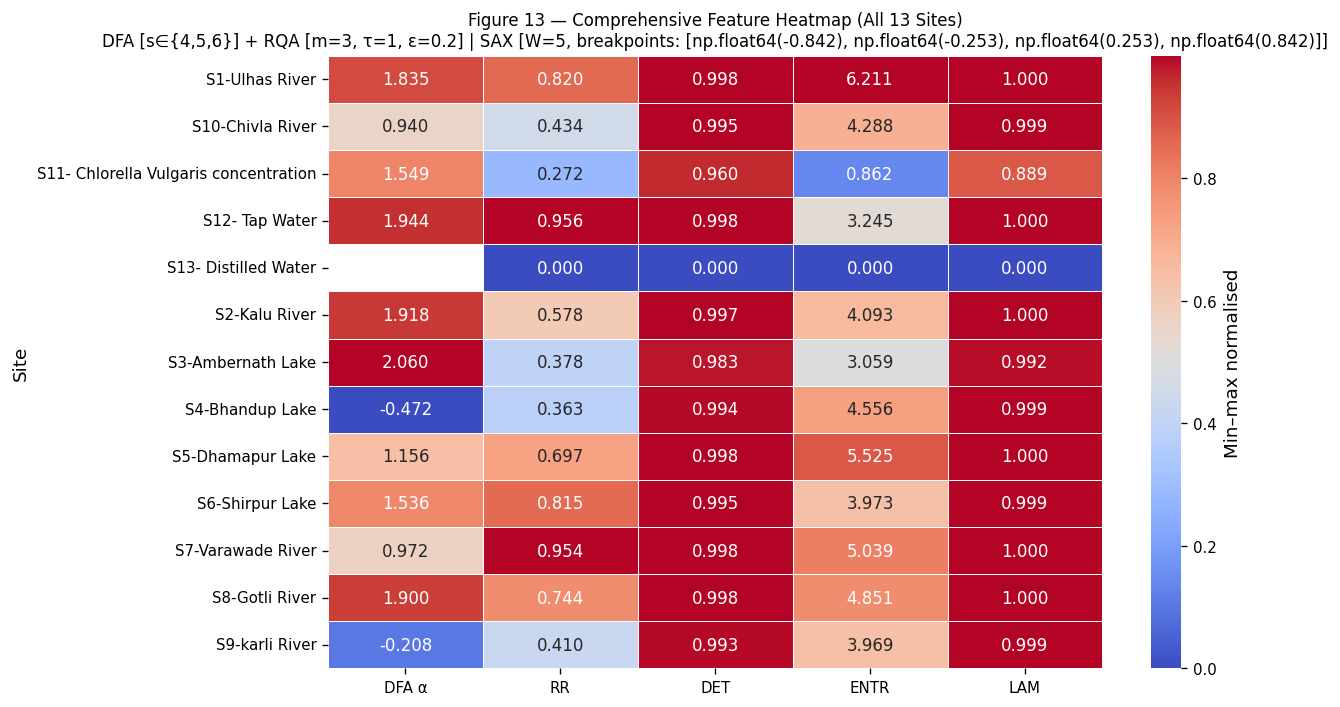

In [ ]:
# ── Figure 13: Final comprehensive heatmap (DFA + RQA + clustering)
heat_data = results_df.set_index('Site')[['DFA α','RR','DET','ENTR','LAM']].astype(float)
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(heat_norm, annot=heat_data.round(3), fmt='.3f',
            cmap='coolwarm', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Min–max normalised'})
ax.set_title(
    f'Figure 13 — Comprehensive Feature Heatmap (All {len(results_df)} Sites)\n'
    f'DFA [s∈{{4,5,6}}] + RQA [m={RQA_M}, τ={RQA_TAU}, ε={RQA_EPS}] | '
    f'SAX [W={ALPHABET_SIZE}, breakpoints: {[round(b,3) for b in BREAKPOINTS]}]',
    fontsize=10)
plt.tight_layout()
plt.savefig(BASE_DIR+'fig13_comprehensive_heatmap.png', bbox_inches='tight')
plt.show()

**Revisions**

Statistical Validations

In [ ]:
"""
Statistical Validation re-analysis for the chlorophyll-a manuscript.

Computes, in order:
  1. Standard one-way ANOVA (the originally reported test, raw N, equal-variance
     assumption) - for reference only, this is what the reviewers flagged.
  2. Per-site lag-1 autocorrelation and the resulting effective sample size
     (n_eff), which corrects for pseudoreplication in sequential readings.
  3. Welch's ANOVA (does not assume equal variance) computed two ways:
       (a) using raw N          - isolates the effect of the equal-variance fix alone
       (b) using effective N    - the effective-sample-size-corrected test
  4. Levene's test and Brown-Forsythe test for variance homogeneity.
  5. Games-Howell post-hoc pairwise comparison (Welch-based, unequal variances OK).

Input : chlorophyll_readings.xlsx  ('Sheet 1', columns Site_ID, Time,
        Chl Temp (C), Chlorophyll (ug/L))
Requires: pandas, numpy, scipy, pingouin, openpyxl
    pip install pingouin openpyxl --break-system-packages   # if not already installed
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

try:
    import pingouin as pg
except ImportError:
    raise SystemExit(
        "This script needs pingouin for Welch's ANOVA / Games-Howell.\n"
        "Install with: pip install pingouin --break-system-packages"
    )

# ----------------------------------------------------------------------
# 1. Load raw data
# ----------------------------------------------------------------------
df_raw = pd.read_excel(
    "chlorophyll_readings.xlsx",
    sheet_name="Sheet 1",
    usecols=["Site_ID", "Time", "Chl Temp (°C)", "Chlorophyll (µg/L)"],
)
df_raw.columns = ["Site_ID", "Time", "chl_temp", "chlorophyll"]
df_raw["Time"] = pd.to_datetime(df_raw["Time"], errors="coerce")
df_raw = df_raw.dropna(subset=["chlorophyll"]).reset_index(drop=True)

sites = sorted(df_raw.Site_ID.unique())
k = len(sites)

# ----------------------------------------------------------------------
# 2. Standard one-way ANOVA
# ----------------------------------------------------------------------
groups = [df_raw[df_raw.Site_ID == s]["chlorophyll"].values for s in sites]
F_standard, p_standard = stats.f_oneway(*groups)

print("=" * 70)
print("1. STANDARD ONE-WAY ANOVA ")
print("=" * 70)
print(f"F = {F_standard:.2f}, p = {p_standard:.3e}")
print("(Raw N per site, assumes independent observations and equal variance)")

# ----------------------------------------------------------------------
# 3. Per-site autocorrelation -> effective sample size
# ----------------------------------------------------------------------
rows = []
for s in sites:
    x = df_raw[df_raw.Site_ID == s].sort_values("Time")["chlorophyll"].values
    n = len(x)
    mean = x.mean()
    var = x.var(ddof=1)

    if var < 1e-9:
        rho1 = 0.0
    else:
        x_c = x - mean
        rho1 = np.corrcoef(x_c[:-1], x_c[1:])[0, 1]
    rho1c = np.clip(rho1, -0.999, 0.999)

    # Effective sample size under an AR(1) approximation
    n_eff = max(n * (1 - rho1c) / (1 + rho1c), 2.0)

    rows.append({"site": s, "n": n, "mean": mean, "var": var,
                 "rho1": rho1c, "n_eff": n_eff})

g = pd.DataFrame(rows)

print("\n" + "=" * 70)
print("2. EFFECTIVE SAMPLE SIZE PER SITE (autocorrelation-based)")
print("=" * 70)
print(g[["site", "n", "rho1", "n_eff"]].round(3).to_string(index=False))
print(f"\nTotal raw N     = {g['n'].sum()}")
print(f"Total effective N = {g['n_eff'].sum():.1f}")

# ----------------------------------------------------------------------
# 4. Welch's ANOVA (unequal-variance F-test), computed with raw N
#    and again with effective N, using the standard Welch formula:
#      w_i     = n_i / var_i
#      F       = [ sum(w_i*(xbar_i - xbar_w)^2) / (k-1) ] / denom
#      denom   = 1 + (2*(k-2)/(k^2-1)) * sum( (1-w_i/sum(w))^2 / (n_i-1) )
#      df1     = k-1
#      df2     = (k^2-1) / (3 * sum( (1-w_i/sum(w))^2 / (n_i-1) ))
# ----------------------------------------------------------------------
def welch_f(g, n_col):
    w = g[n_col] / g["var"].replace(0, 1e-9)
    xbar_w = (w * g["mean"]).sum() / w.sum()
    num = (w * (g["mean"] - xbar_w) ** 2).sum() / (k - 1)
    term = ((1 - w / w.sum()) ** 2 / (g[n_col] - 1)).sum()
    denom = 1 + (2 * (k - 2) / (k**2 - 1)) * term
    F = num / denom
    df1 = k - 1
    df2 = (k**2 - 1) / (3 * term)
    p = stats.f.sf(F, df1, df2)
    return F, df1, df2, p

F_welch_raw, df1_wr, df2_wr, p_welch_raw = welch_f(g, "n")
F_welch_eff, df1_we, df2_we, p_welch_eff = welch_f(g, "n_eff")

print("\n" + "=" * 70)
print("3. WELCH'S ANOVA (unequal-variance F-test)")
print("=" * 70)
print(f"Using raw N       : F = {F_welch_raw:.4e}, df=({df1_wr:.1f},{df2_wr:.1f}), "
      f"p = {p_welch_raw:.3e}")
print(f"Using effective N : F = {F_welch_eff:.4e}, df=({df1_we:.1f},{df2_we:.1f}), "
      f"p = {p_welch_eff:.3e}")
print(f"\nNote: F_welch_raw / F_welch_eff = {F_welch_raw / F_welch_eff:.2f}")
print("(This ratio - not a comparison to the standard ANOVA F above - is the")
print(" valid basis for any 'X times lower/higher' statement in the manuscript.)")

# ----------------------------------------------------------------------
# 5. Levene's test and Brown-Forsythe test (variance homogeneity)
# ----------------------------------------------------------------------
lev_stat, lev_p = stats.levene(*groups, center="mean")     # Levene's test
bf_stat, bf_p = stats.levene(*groups, center="median")      # Brown-Forsythe

print("\n" + "=" * 70)
print("4. VARIANCE HOMOGENEITY TESTS")
print("=" * 70)
print(f"Levene's test (mean-centered)      : W = {lev_stat:.2f}, p = {lev_p:.3e}")
print(f"Brown-Forsythe test (median-centered): W = {bf_stat:.2f}, p = {bf_p:.3e}")

# ----------------------------------------------------------------------
# 6. Games-Howell post-hoc (Welch-based, does not assume equal variance)
# ----------------------------------------------------------------------
df_long = df_raw[["Site_ID", "chlorophyll"]].dropna()
gh = pg.pairwise_gameshowell(dv="chlorophyll", between="Site_ID", data=df_long)
n_sig = (gh["pval"] < 0.05).sum()
n_total = len(gh)

print("\n" + "=" * 70)
print("5. GAMES-HOWELL POST-HOC (pairwise, unequal variance)")
print("=" * 70)
print(f"{n_sig} of {n_total} site pairs significant at p < 0.05")
gh.to_csv("games_howell_results.csv", index=False)
print("Full pairwise results saved to games_howell_results.csv")

# ----------------------------------------------------------------------
# 7. Summary block
# ----------------------------------------------------------------------
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Standard ANOVA                             : F = {F_standard:.2f}, p = {p_standard:.3e}")
print(f"Welch's ANOVA, effective N                : F = {F_welch_eff:.2e}, "
      f"df=({df1_we:.0f}, {df2_we:.1f}), p = {p_welch_eff:.2e}")
print(f"Levene's test                              : W = {lev_stat:.1f}, p < 0.001" if lev_p < 0.001
      else f"Levene's test: W = {lev_stat:.1f}, p = {lev_p:.3e}")
print(f"Brown-Forsythe test                        : W = {bf_stat:.1f}, p < 0.001" if bf_p < 0.001
      else f"Brown-Forsythe test: W = {bf_stat:.1f}, p = {bf_p:.3e}")
print(f"Games-Howell significant pairs              : {n_sig} of {n_total}")
print(f"Effective total N vs raw total N            : {g['n_eff'].sum():.0f} vs {g['n'].sum()}")
lowest = g.nsmallest(2, "n_eff")[["site", "n", "n_eff"]]
print(f"Lowest effective N sites                    :\n{lowest.to_string(index=False)}")

Mean Chlorophyll-a with 95% Confidence Intervals

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------------------------------------------------
# 1. Load raw data
# ----------------------------------------------------------------------
df_raw = pd.read_excel(
    "chlorophyll_readings.xlsx",
    sheet_name="Sheet 1",
    usecols=["Site_ID", "Time", "Chl Temp (°C)", "Chlorophyll (µg/L)"],
)
df_raw.columns = ["Site_ID", "Time", "chl_temp", "chlorophyll"]
df_raw["Time"] = pd.to_datetime(df_raw["Time"], errors="coerce")
df_raw = df_raw.dropna(subset=["chlorophyll"]).reset_index(drop=True)

# ----------------------------------------------------------------------
# 2. Per-site mean, raw N, effective N (autocorrelation),
#    and 95% CI half-widths (raw vs. effective)
# ----------------------------------------------------------------------
rows = []
for site in sorted(df_raw.Site_ID.unique()):
    x = df_raw[df_raw.Site_ID == site].sort_values("Time")["chlorophyll"].values
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)

    # lag-1 autocorrelation
    if sd < 1e-9:
        rho1 = 0.0
    else:
        x_c = x - mean
        rho1 = np.corrcoef(x_c[:-1], x_c[1:])[0, 1]
    rho1c = np.clip(rho1, -0.999, 0.999)

    # effective sample size (AR(1) approximation)
    n_eff = max(n * (1 - rho1c) / (1 + rho1c), 2.0)

    se_raw = sd / np.sqrt(n)
    se_eff = sd / np.sqrt(n_eff)

    ci_raw = 1.96 * se_raw
    t_crit_eff = stats.t.ppf(0.975, df=max(n_eff - 1, 1))
    ci_eff = t_crit_eff * se_eff

    rows.append(
        {
            "Site": site,
            "mean": mean,
            "n": n,
            "n_eff": n_eff,
            "ci_raw": ci_raw,
            "ci_eff": ci_eff,
        }
    )

d = pd.DataFrame(rows).sort_values("mean").reset_index(drop=True)


label_map = {
    "S13- Distilled Water": "S13-Distilled Water",
    "S12- Tap Water": "S12-Tap Water",
    "S11- Chlorella Vulgaris concentration": "S11-Chlorella Vulgaris",
}
d["label"] = d["Site"].apply(lambda s: label_map.get(s, s))

# ----------------------------------------------------------------------
# 3. Welch's ANOVA (effective-N weighted) for the title

# ----------------------------------------------------------------------
k = len(d)
w = d["n_eff"] / (d["mean"].sub(d["mean"]).pow(2) + 1)  # placeholder, replaced below

# Proper per-group variance needed for Welch's F; recompute directly from data
group_stats = []
for site in d["Site"]:
    x = df_raw[df_raw.Site_ID == site]["chlorophyll"].values
    group_stats.append({"site": site, "mean": x.mean(), "var": x.var(ddof=1)})
g = pd.DataFrame(group_stats).merge(
    d[["Site", "n_eff"]], left_on="site", right_on="Site"
)

w = g["n_eff"] / g["var"].replace(0, 1e-9)
xbar_w = (w * g["mean"]).sum() / w.sum()
num = (w * (g["mean"] - xbar_w) ** 2).sum() / (k - 1)
term = ((1 - w / w.sum()) ** 2 / (g["n_eff"] - 1)).sum()
denom = 1 + (2 * (k - 2) / (k**2 - 1)) * term
F_eff = num / denom
df1_eff = k - 1
df2_eff = (k**2 - 1) / (3 * term)
p_eff = stats.f.sf(F_eff, df1_eff, df2_eff)

# ----------------------------------------------------------------------
# 4. Plot — horizontal bar chart, corrected error bars
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

y_pos = np.arange(len(d))
ax.barh(y_pos, d["mean"], xerr=d["ci_eff"], color="#4C72B0",
        edgecolor="black", height=0.6, capsize=4,
        error_kw={"elinewidth": 1.2, "capthick": 1.2})

ax.set_yticks(y_pos)
ax.set_yticklabels(d["label"])
ax.set_xlabel("Chlorophyll-a mean ± 95% CI (µg/L) — effective-N")
ax.set_title(
    f"Welch's ANOVA (autocorrelation): "
    f"F={F_eff:.2e}, p={p_eff:.2e}"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figure12_corrected.png", dpi=300)
print("Saved figure12_corrected.png")

# ----------------------------------------------------------------------
# 5. Print the numbers table for the caption / cross-check against text
# ----------------------------------------------------------------------
print("\nPer-site values used in the figure:")
print(
    d[["label", "mean", "n", "n_eff", "ci_raw", "ci_eff"]]
    .round(2)
    .to_string(index=False)
)
print(f"\nCorrected Welch F = {F_eff:.4e}, df=({df1_eff:.1f}, {df2_eff:.1f}), p = {p_eff:.4e}")

Revisions 4

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats, signal as scipy_signal
from scipy.stats import norm as sp_norm

df_raw = pd.read_excel(
    "chlorophyll_readings.xlsx",
    sheet_name="Sheet 1",
    usecols=["Site_ID", "Time", "Chl Temp (°C)", "Chlorophyll (µg/L)"],
)
df_raw.columns = ["Site_ID", "Time", "chl_temp", "chlorophyll"]
df_raw["Time"] = pd.to_datetime(df_raw["Time"], errors="coerce")
df_raw = df_raw.dropna(subset=["chlorophyll"]).reset_index(drop=True)

sites = sorted(df_raw.Site_ID.unique())

DFA_SCALES = [4, 5, 6]
RQA_M, RQA_TAU, RQA_EPS = 3, 1, 0.20
ALPHABET = "abcde"
ALPHABET_SIZE = 5


def preprocess(series, sg_window=5, sg_poly=2):
    """Savitzky-Golay filter + Z-score normalization (same as the rest
    of the pipeline)."""
    s = np.array(series, dtype=float)
    if len(s) >= sg_window:
        s = scipy_signal.savgol_filter(s, window_length=sg_window, polyorder=sg_poly)
    mu, sigma = s.mean(), s.std()
    if sigma < 1e-9:
        return np.zeros_like(s)
    return (s - mu) / sigma


def dfa(x, scales=DFA_SCALES):
    Y = np.cumsum(x - x.mean())
    N = len(Y)
    F_s, valid = [], []
    for s in scales:
        if N < 2 * s:
            continue
        n_seg = N // s
        residuals = []
        for k in range(n_seg):
            seg = Y[k * s:(k + 1) * s]
            t = np.arange(len(seg))
            p = np.polyfit(t, seg, 1)
            residuals.extend((seg - np.polyval(p, t)) ** 2)
        F_s.append(np.sqrt(np.mean(residuals)))
        valid.append(s)
    if len(valid) < 2:
        return np.nan
    return float(np.polyfit(np.log(valid), np.log(F_s), 1)[0])


def embed(ts, m=RQA_M, tau=RQA_TAU):
    N = len(ts) - (m - 1) * tau
    return np.array([ts[i:i + m * tau:tau] for i in range(N)])


def rqa_det(ts, eps=RQA_EPS, lmin=2):
    X = embed(ts)
    dist = np.linalg.norm(X[:, None] - X[None, :], axis=2)
    max_d = dist.max()
    if max_d < 1e-9:
        return 0.0
    R = dist <= eps * max_d
    N = R.shape[0]
    total_recur = R.sum()
    dl_sum = 0
    for k in range(-(N - 1), N):
        if k == 0:
            continue
        d = np.diag(R, k)
        count = 0
        for v in d:
            if v:
                count += 1
            elif count >= lmin:
                dl_sum += count
                count = 0
            else:
                count = 0
        if count >= lmin:
            dl_sum += count
    return dl_sum / (total_recur + 1e-9)


def sax_complexity(ts, w=16):
    n = len(ts)
    seg = n / w
    paa = np.array([ts[int(j * seg):int((j + 1) * seg)].mean() for j in range(w)])
    bp = sp_norm.ppf(np.linspace(0, 1, ALPHABET_SIZE + 1)[1:-1])
    symbols = [ALPHABET[np.searchsorted(bp, v)] for v in paa]
    return len(set(symbols)) / ALPHABET_SIZE


def effective_n(x):
    """Effective sample size correcting for lag-1 autocorrelation
    (Bayley & Hammersley, 1946): n_eff = n*(1-rho)/(1+rho)."""
    n = len(x)
    if np.std(x) < 1e-9:
        return float(n)
    xc = x - x.mean()
    rho = np.corrcoef(xc[:-1], xc[1:])[0, 1]
    rho = np.clip(rho, -0.999, 0.999)
    return max(n * (1 - rho) / (1 + rho), 2.0)


# =================================================================
# CELL: Table 7 - Effective-Sample-Size-Corrected Temperature-
#       Chlorophyll-a Correlation
#       (uses samples sorted by Time - see note above)
# =================================================================
rows_t7 = []
for s in sites:
    sub = df_raw[df_raw.Site_ID == s].sort_values("Time")  # TIME-SORTED
    temp = sub["chl_temp"].values.astype(float)
    chlo = sub["chlorophyll"].values.astype(float)
    n = len(temp)

    if np.std(temp) < 1e-9 or np.std(chlo) < 1e-9:
        continue  # skip constant-signal references (e.g. distilled water)

    r, p_raw = stats.pearsonr(temp, chlo)

    n_eff = min(effective_n(temp), effective_n(chlo))  # conservative choice
    df_eff = max(n_eff - 2, 1)
    t_stat = r * np.sqrt(df_eff / (1 - r ** 2 + 1e-12))
    p_eff = 2 * stats.t.sf(np.abs(t_stat), df_eff)

    rows_t7.append({
        "Site": s,
        "r": round(r, 2),
        "N_raw": n,
        "N_effective": round(n_eff, 1),
        "p_raw": p_raw,
        "p_effective_N": p_eff,
    })

table7 = pd.DataFrame(rows_t7)
table7


# =================================================================
# CELL: Table 8 - DFA, RQA, and SAX Results Before and After
#       Temperature Adjustment
#       (uses original file row order - matches Tables 3/4)
# =================================================================
rows_t8 = []
for s in sites:
    sub = df_raw[df_raw.Site_ID == s]  # FILE ORDER (no re-sort)
    chlo = sub["chlorophyll"].values.astype(float)
    temp = sub["chl_temp"].values.astype(float)

    # --- Unadjusted ---
    proc_orig = preprocess(chlo)
    a_orig = dfa(proc_orig)
    det_orig = rqa_det(proc_orig) if len(proc_orig) > (RQA_M - 1) * RQA_TAU + 5 else np.nan
    sax_orig = sax_complexity(proc_orig) if len(proc_orig) >= 16 else np.nan

    # --- Temperature-adjusted: residuals of chlorophyll ~ temperature (linear) ---
    if np.std(temp) > 1e-9:
        b = np.polyfit(temp, chlo, 1)
        resid = chlo - np.polyval(b, temp)
    else:
        resid = chlo - chlo.mean()

    proc_adj = preprocess(resid)
    a_adj = dfa(proc_adj)
    det_adj = rqa_det(proc_adj) if len(proc_adj) > (RQA_M - 1) * RQA_TAU + 5 else np.nan
    sax_adj = sax_complexity(proc_adj) if len(proc_adj) >= 16 else np.nan

    rows_t8.append({
        "Site": s,
        "DFA_alpha_unadjusted": round(a_orig, 4) if not np.isnan(a_orig) else np.nan,
        "DFA_alpha_temp_adjusted": round(a_adj, 4) if not np.isnan(a_adj) else np.nan,
        "RQA_DET_unadjusted": round(det_orig, 4) if not np.isnan(det_orig) else np.nan,
        "RQA_DET_temp_adjusted": round(det_adj, 4) if not np.isnan(det_adj) else np.nan,
        "SAX_complexity_unadjusted": round(sax_orig, 3) if not np.isnan(sax_orig) else np.nan,
        "SAX_complexity_temp_adjusted": round(sax_adj, 3) if not np.isnan(sax_adj) else np.nan,
    })

table8 = pd.DataFrame(rows_t8)
table8